# Exploratory Data Analysis

### Import modules and data

In [118]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import libpysal
import esda
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [119]:
# data import
DATA_PATH = "../data/updated_data.geojson"
gdf = gpd.read_file(DATA_PATH)

### Check dataframe dimensions and variables' distributions

In [120]:
print(f"The dataframe has dimensions {gdf.shape}") # 107 provinces, 63 variables
print(f"The dataframe has {gdf.select_dtypes(include='number').shape[1]} numerical variables") # 47 actual variables

nan_cols = gdf.select_dtypes(exclude='number').columns # only codes and names in non-numeric
print(f"The non numerical columns are: {nan_cols.tolist()}")
print("\tNon-numerical are just codes and names")

The dataframe has dimensions (107, 55)
The dataframe has 50 numerical variables
The non numerical columns are: ['geo_point_2d', 'rip_name', 'reg_name', 'prov_name', 'geometry']
	Non-numerical are just codes and names


In [121]:
summary = (
    gdf.select_dtypes(include='number').describe()
        .T[['mean', 'std', 'min', 'max']].round(2)
)

print(summary)

                                         mean        std       min         max
population                          551683.49  602448.84  80564.00  4216874.00
unempl_rate                              8.45       4.45      2.30       21.50
part_rate                                0.05       0.01      0.03        0.06
empl_growth                              2.32       3.35     -4.76       17.65
inact_rate                              34.26       8.30     23.50       55.50
fem_edu_rate                             0.18       0.03      0.12        0.27
male_edu_rate                            0.15       0.03      0.08        0.25
service_empl_rate                        0.67       0.07      0.52        0.87
GDP                                      0.03       0.01      0.02        0.07
n_large_comp                             0.10       0.06      0.00        0.37
n_self_empl                              0.24       0.03      0.17        0.32
young_neet                              18.47       

Evaluating the distributions shows that `part_rate` displays very low values (min = 0.03, max = 0.06), thus showing a very low standard deviation -> Boxplots will be flat.

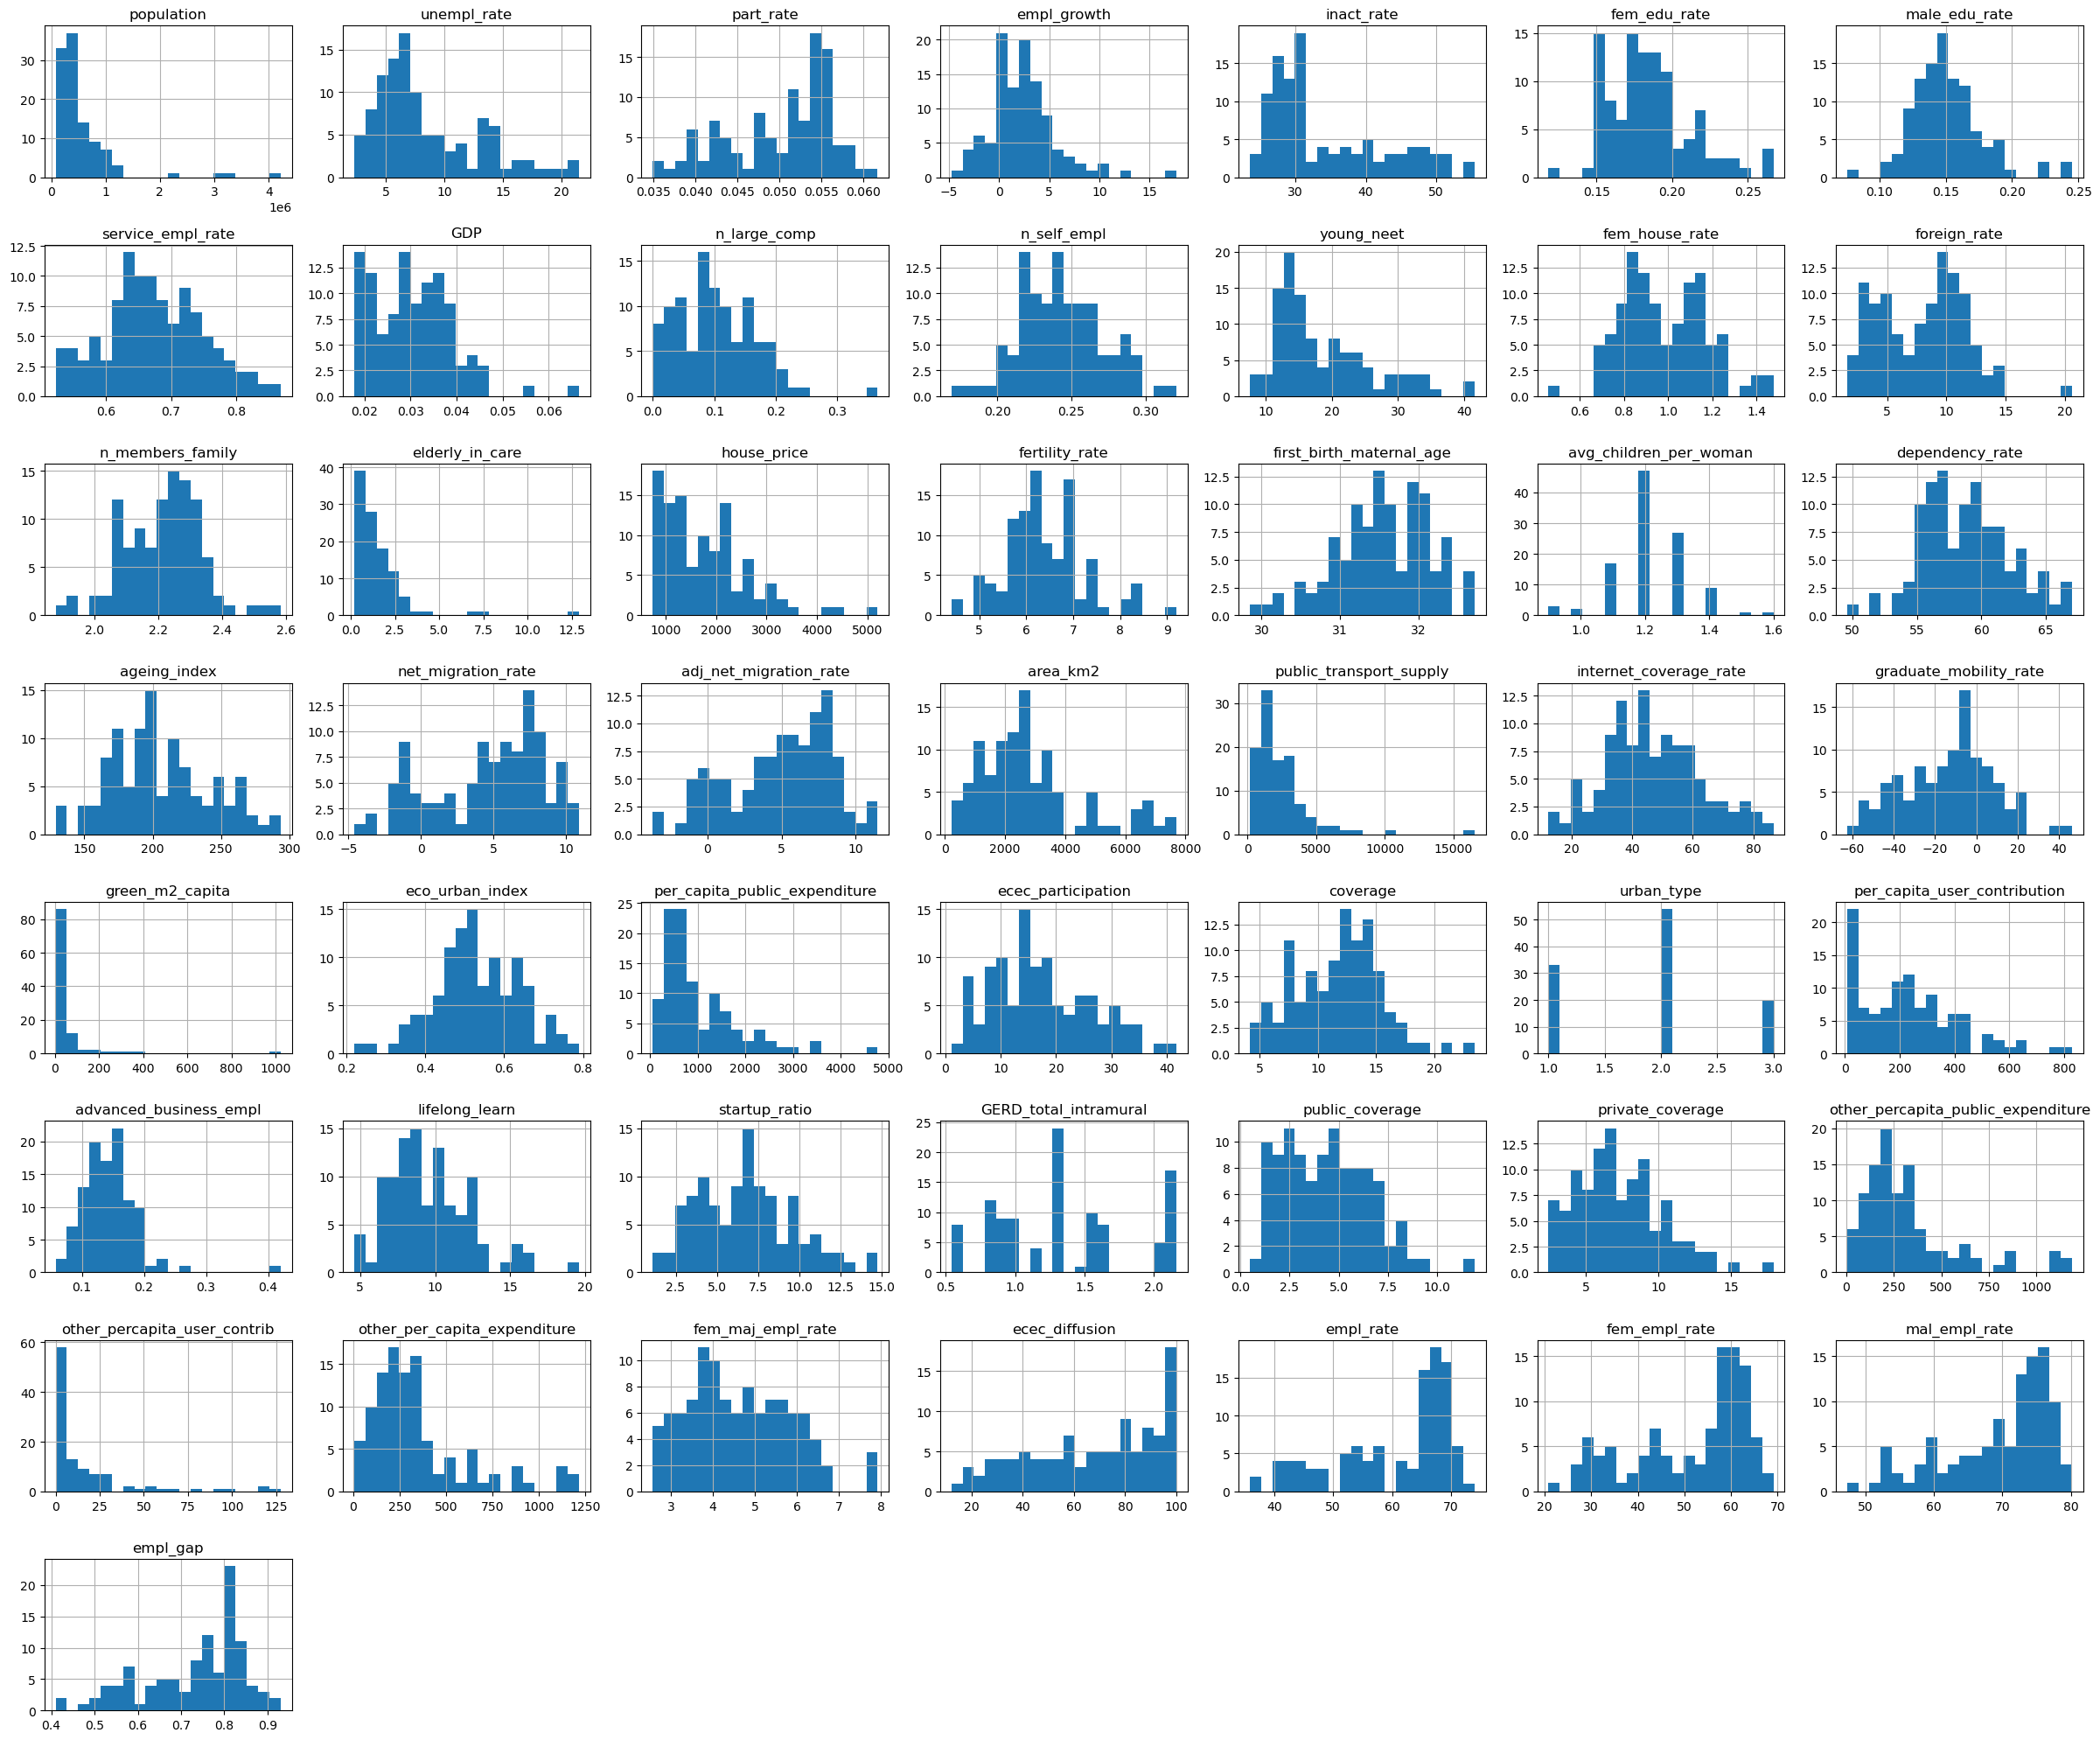

In [122]:
gdf.hist(figsize=(24, 20), bins=20)
plt.tight_layout()
plt.show()

### Check weird values: NAs and 0s

In [123]:
gdf.isnull().sum().sort_values(ascending=False) # no missing values

geo_point_2d                          0
startup_ratio                         0
internet_coverage_rate                0
graduate_mobility_rate                0
green_m2_capita                       0
eco_urban_index                       0
per_capita_public_expenditure         0
ecec_participation                    0
coverage                              0
urban_type                            0
per_capita_user_contribution          0
advanced_business_empl                0
lifelong_learn                        0
GERD_total_intramural                 0
area_km2                              0
public_coverage                       0
private_coverage                      0
other_percapita_public_expenditure    0
other_percapita_user_contrib          0
other_per_capita_expenditure          0
fem_maj_empl_rate                     0
ecec_diffusion                        0
empl_rate                             0
fem_empl_rate                         0
mal_empl_rate                         0


In [124]:
(gdf == 0).sum().sort_values(ascending=False) # no missing values

other_percapita_user_contrib          19
empl_growth                           15
n_large_comp                           3
geo_point_2d                           0
startup_ratio                          0
graduate_mobility_rate                 0
green_m2_capita                        0
eco_urban_index                        0
per_capita_public_expenditure          0
ecec_participation                     0
coverage                               0
urban_type                             0
per_capita_user_contribution           0
advanced_business_empl                 0
lifelong_learn                         0
public_coverage                        0
GERD_total_intramural                  0
public_transport_supply                0
private_coverage                       0
other_percapita_public_expenditure     0
other_per_capita_expenditure           0
fem_maj_empl_rate                      0
ecec_diffusion                         0
empl_rate                              0
fem_empl_rate   

There are three variables with zero values:
- `other_percapita_user_contrib`: 19 zero values
- `empl_growth`: 15 values
- `n_large_comp`: 3 values

In [125]:
def plot_provinces_by_value(geodf, var, sign, value):
    """
    Given a geodataframe, variable, sign and value, plots the map of provinces satisfying a given condition
    Parameters
    ----------
    geodf : GeoDataFrame
        The geodataframe containing the data
    var : str
        The variable/column name to filter on
    sign : str
        The sign of the condition ('>', '<', '=')
    value : float
        The value to compare against
    Returns
    -------
    None
    -----------
    Displays a plot of the provinces satisfying the condition along with their names in a text box
    """

    if sign == '>':
        subset = geodf[geodf[var] > value]
    elif sign == '<':
        subset = geodf[geodf[var] < value]
    elif sign == '=':
        subset = geodf[geodf[var] == value]
    else:
        raise ValueError("Sign must be one of: '>', '<', '='")

    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot polygons
    subset.plot(ax=ax, color="lightblue", edgecolor="black")

    # Turn off axis
    ax.axis("off")

    # Create list of province names
    prov_names = subset["prov_name"].tolist()

    # Add text box on the right
    text = "\n".join(prov_names)
    plt.text(
        1.02, 0.5, text,
        transform=ax.transAxes,
        fontsize=9,
        va="center",
        ha="left"
    )
    plt.title(f"Provinces where {var} {sign} {value}")
    plt.tight_layout()
    plt.show()

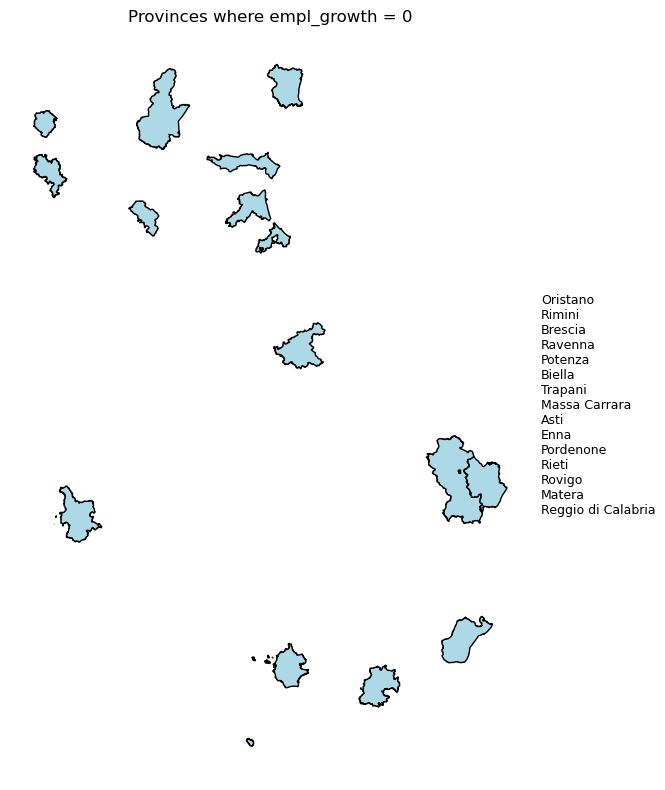

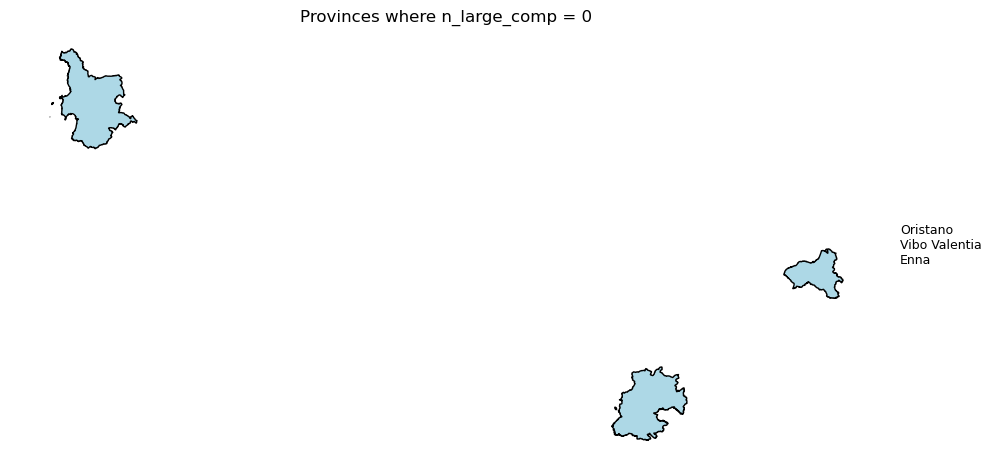

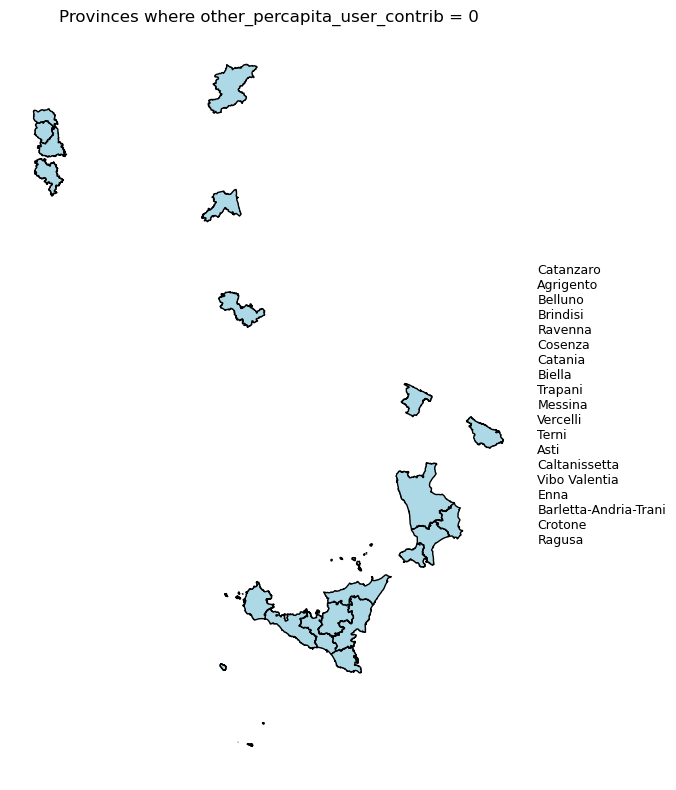

In [126]:
for var in (gdf == 0).sum()[lambda x: x > 0].index.tolist():
    plot_provinces_by_value(gdf, var, '=', 0)

- While zero values for "number of large companies" are to be expected, for other variables the explanation is not as intuitive. <br>
- `other_percapita_user_contributions` display somewhat of a regional dimension, as most of Sicily displays zero values. However this is not the case for other observations. <br>
- The zero values of employment growth appear randomly distributed, even though it's curious for employment to remain exactly constant.

### Correlation Analysis

In [127]:
gdf_num = gdf.select_dtypes(include='number')
gdf_num.corr(method='spearman').style.background_gradient(cmap='coolwarm')

,population,unempl_rate,part_rate,empl_growth,inact_rate,fem_edu_rate,male_edu_rate,service_empl_rate,GDP,n_large_comp,n_self_empl,young_neet,fem_house_rate,foreign_rate,n_members_family,elderly_in_care,house_price,fertility_rate,first_birth_maternal_age,avg_children_per_woman,dependency_rate,ageing_index,net_migration_rate,adj_net_migration_rate,area_km2,public_transport_supply,internet_coverage_rate,graduate_mobility_rate,green_m2_capita,eco_urban_index,per_capita_public_expenditure,ecec_participation,coverage,urban_type,per_capita_user_contribution,advanced_business_empl,lifelong_learn,startup_ratio,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate,ecec_diffusion,empl_rate,fem_empl_rate,mal_empl_rate,empl_gap
population,1.000000,-0.034929,0.145712,0.110268,-0.049921,0.224338,0.333735,0.104720,0.259517,0.416225,-0.214101,-0.091800,-0.264886,0.124630,0.276592,-0.066161,0.489183,0.446802,0.017664,0.320057,-0.447770,-0.536700,-0.036286,-0.008368,0.358647,0.557967,0.321329,0.314613,-0.102342,-0.021599,0.029477,-0.058738,-0.032348,-0.432880,-0.023257,0.418552,0.047367,0.224330,0.034496,-0.276730,0.137851,-0.043055,0.034069,-0.031672,0.350056,0.226726,0.068742,0.032613,0.106311,-0.021580
unempl_rate,-0.034929,1.000000,-0.800241,-0.107669,0.748986,-0.156348,-0.085187,0.446237,-0.806482,-0.548096,0.387124,0.824471,0.728629,-0.673527,0.265989,-0.466809,-0.553148,0.119134,-0.155203,-0.123100,-0.291827,-0.053109,-0.643462,-0.612218,0.077059,-0.291947,0.083447,-0.679684,-0.319402,-0.598679,-0.551809,-0.558613,-0.643399,-0.086614,-0.656018,-0.593136,-0.393227,-0.192530,-0.452024,-0.384518,-0.577175,-0.253311,-0.378448,-0.285296,0.298699,-0.418830,-0.865425,-0.826051,-0.870491,-0.739491
part_rate,0.145712,-0.800241,1.000000,0.192054,-0.953640,0.331707,0.254727,-0.315080,0.857805,0.593856,-0.428329,-0.808420,-0.884490,0.792325,-0.296078,0.453373,0.655557,-0.098676,0.234509,0.085619,0.234337,0.006353,0.759970,0.735091,-0.071583,0.369023,0.094488,0.832111,0.373956,0.524586,0.704883,0.692780,0.658565,0.004940,0.776828,0.671242,0.550842,0.225677,0.541055,0.492045,0.509641,0.291062,0.456988,0.323772,-0.195625,0.550590,0.956058,0.929044,0.887657,0.840568
empl_growth,0.110268,-0.107669,0.192054,1.000000,-0.157955,0.004400,0.035129,0.052515,0.094671,-0.064491,0.051796,-0.103778,-0.142945,0.026649,0.106060,0.040646,0.175418,0.100416,0.058074,0.138196,-0.077739,-0.074738,0.061807,0.078573,-0.089937,0.023931,0.083307,0.066646,-0.172474,-0.089636,0.114133,0.083393,-0.002305,-0.141719,0.030960,-0.002923,0.099189,-0.137713,-0.018668,0.032039,-0.012341,0.140537,0.055104,0.133582,-0.025628,0.149533,0.157514,0.143731,0.138531,0.092468
inact_rate,-0.049921,0.748986,-0.953640,-0.157955,1.000000,-0.319067,-0.242993,0.259336,-0.822604,-0.571853,0.439498,0.792975,0.811357,-0.750909,0.464089,-0.452788,-0.626308,0.234186,-0.229066,-0.006603,-0.432334,-0.204518,-0.802063,-0.776503,0.073317,-0.330153,-0.067577,-0.816700,-0.387343,-0.542470,-0.766133,-0.723894,-0.688109,-0.051183,-0.820919,-0.625236,-0.591517,-0.216135,-0.585633,-0.586758,-0.484100,-0.325117,-0.404654,-0.357824,0.172537,-0.526385,-0.969710,-0.953194,-0.878587,-0.867987
fem_edu_rate,0.224338,-0.156348,0.331707,0.004400,-0.319067,1.000000,0.948471,0.227965,0.364486,0.344132,0.008758,-0.327708,-0.301848,0.244029,-0.227316,-0.129483,0.319868,-0.033811,0.536507,-0.171274,0.068383,0.062135,0.184729,0.147430,0.083564,0.437294,0.316779,0.416616,0.169738,0.203873,0.318707,0.341399,0.324634,0.001088,0.341317,0.505124,0.453668,0.488419,0.133804,0.357413,0.123881,-0.054233,0.387612,-0.037981,0.213454,0.189372,0.290319,0.310452,0.200151,0.302923
male_edu_rate,0.333735,-0.085187,0.254727,0.035129,-0.242993,0.948471,1.000000,0.295051,0.322930,0.331416,-0.033523,-0.248654,-0.263132,0.190766,-0.159251,-0.197120,0.359088,0.053417,0.505136,-0.094298,0.005173,-0.011065,0.152577,0.129200,0.045377,0.462579,

The table above is by no mean pretty, but it is very informative. Two pieces of information are evident:
- Many potential covariates are strongly correlated
- `fem_empl_rate`, our response variable, is strongly correlated with:
    - positively:
        - part_rate
        - empl_rate
        - gdp
        - foreign_rate
        - house_price
        - migration variables
        - graduate_mobility_rate
        - *ecec variables*
    - negatively:
        - young_neet
        - fem_house_rate
        - inactivity rate
        - unemployment rate

### Focus on subset of relevant variables

Some variables have stronger theoretical underpinnings. Thus, I will inspect these in greater detail:
- female employment rate
- unemployment rate
- fem_edu_rate
- GDP
- service_empl_rate 
- avg_children_per_woman
- dependency_rate
- graduate_mobility_rate
- per_capita_public_expenditure
- ecec_participation
- coverage
- per_capita_user_contribution
- fem_maj_empl_rate

In [128]:
var_subset = [
    'prov_name',
    'rip_name',
    'fem_empl_rate', 
    'unemp_rate', 
    'fem_edu_rate',
    'gdp',
    'service_empl_rate', 
    'dependency_rate',
    'graduate_mobility_rate',
    'per_capita_public_expenditure',
    'ecec_participation',
    'coverage',
    'per_capita_user_contribution',
    'fem_maj_empl_rate']

gdf_subset = gdf[[col for col in gdf.columns if col in var_subset]]



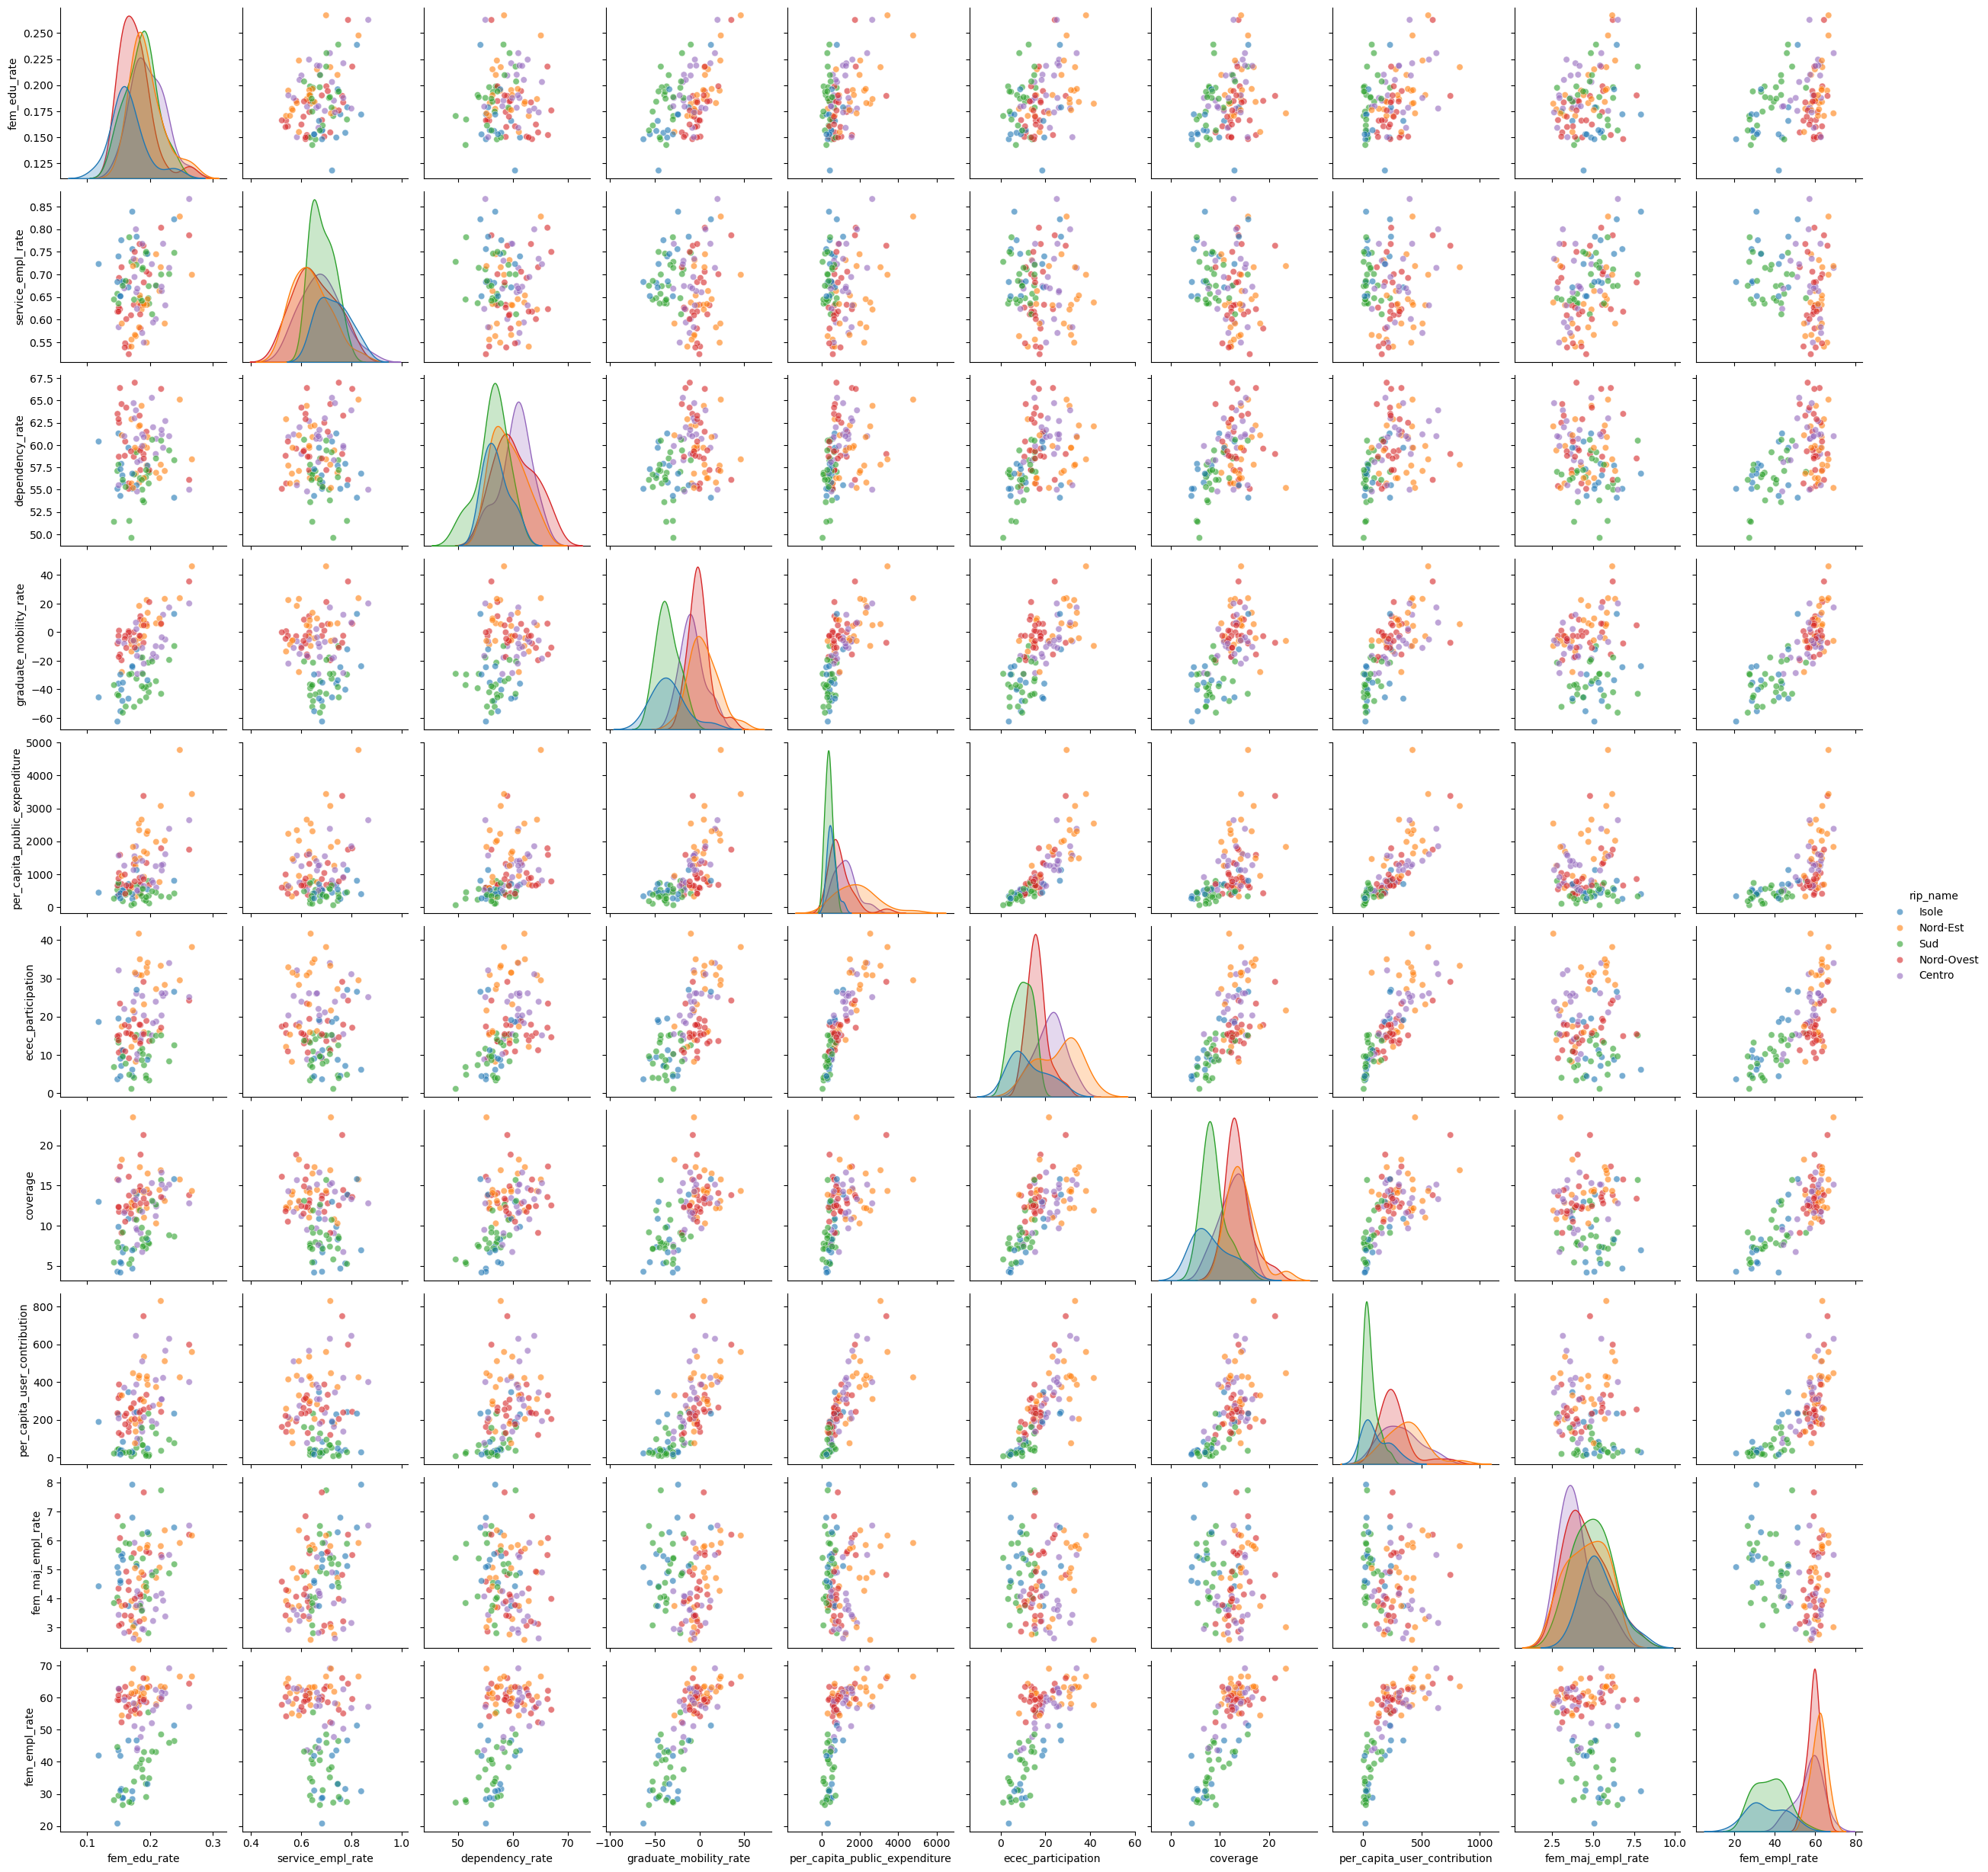

In [129]:
numeric_cols = gdf_subset.select_dtypes(include='number').columns

sns.pairplot(
    gdf_subset,
    vars=numeric_cols,
    hue='rip_name',  # color by this variable
    plot_kws={'alpha': 0.6}
)
plt.show()

### Focus on ECEC variables

Analize only the variables related to ECEC and women labour

In [130]:
ecec_variables = [
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "per_capita_public_expenditure", "per_capita_user_contribution",
    "other_percapita_public_expenditure", "other_percapita_user_contrib",
    "other_per_capita_expenditure"
]

# Variabili Lavoro Femminile
labour_variables = [
    "fem_empl_rate", "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate"
]


eda_df = gdf_num[ecec_variables + labour_variables]

In [131]:
print(eda_df.std().sort_values()) # very different standard deviations

part_rate                               0.006247
fem_edu_rate                            0.027722
fem_house_rate                          0.192405
fem_maj_empl_rate                       1.223030
public_coverage                         2.197102
private_coverage                        3.013569
coverage                                3.716104
unempl_rate                             4.447776
ecec_participation                      8.927299
fem_empl_rate                          12.411734
other_percapita_user_contrib           26.321117
per_capita_user_contribution          177.678746
other_percapita_public_expenditure    256.434322
other_per_capita_expenditure          267.566490
per_capita_public_expenditure         818.311320
dtype: float64


In [132]:
stdev_sorted = eda_df.std().sort_values().index
variables_by_stdev = {
    "low variance": stdev_sorted[:8].tolist(),
    "medium variance" : stdev_sorted[8:11].tolist(),
    "high variance" : stdev_sorted[11:-1].tolist(),
    "per capita public expenditure" : [stdev_sorted[-1]]
    }


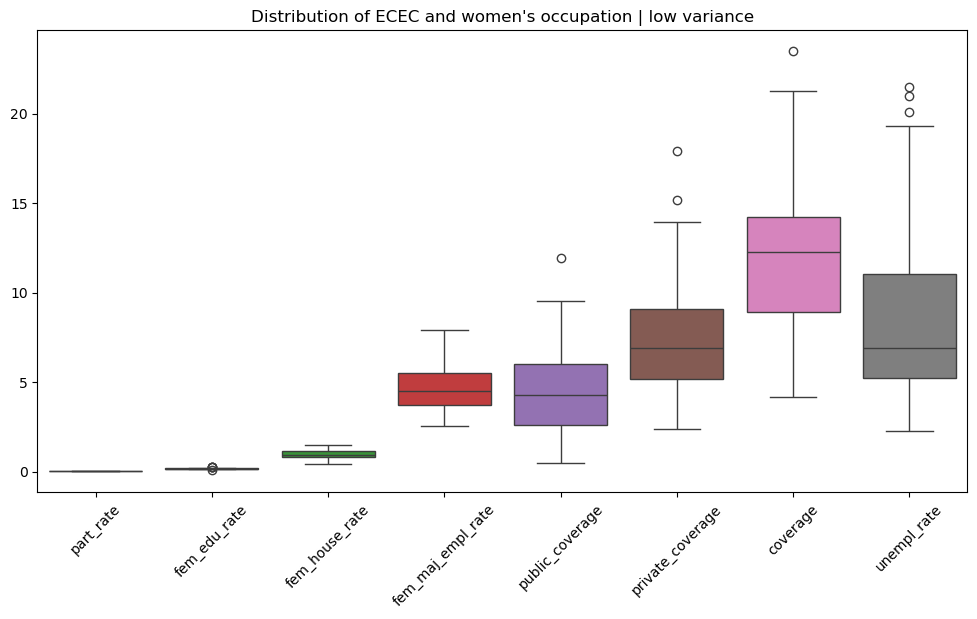

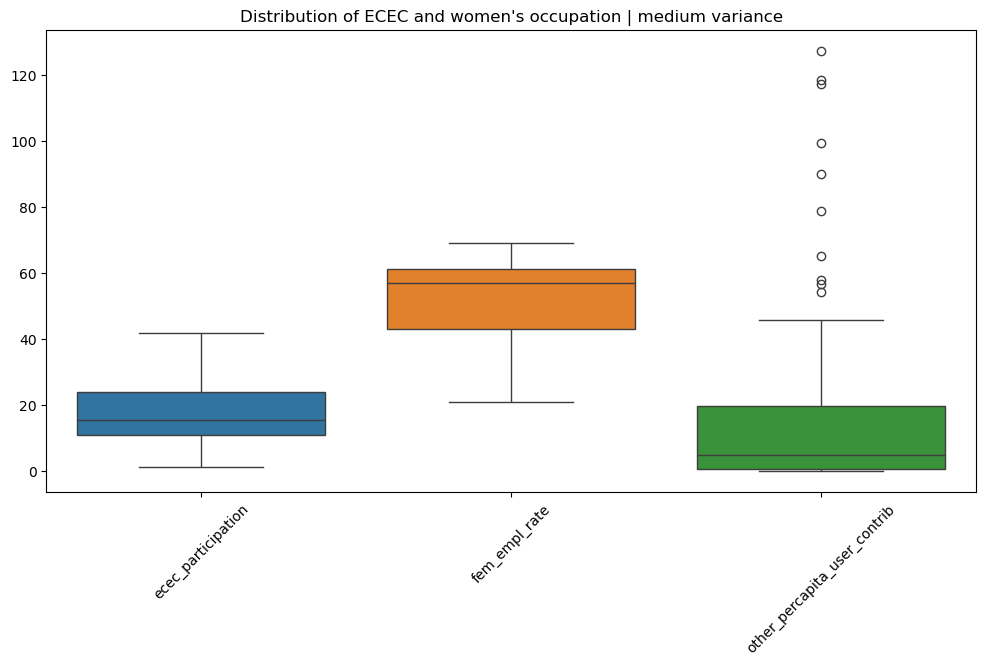

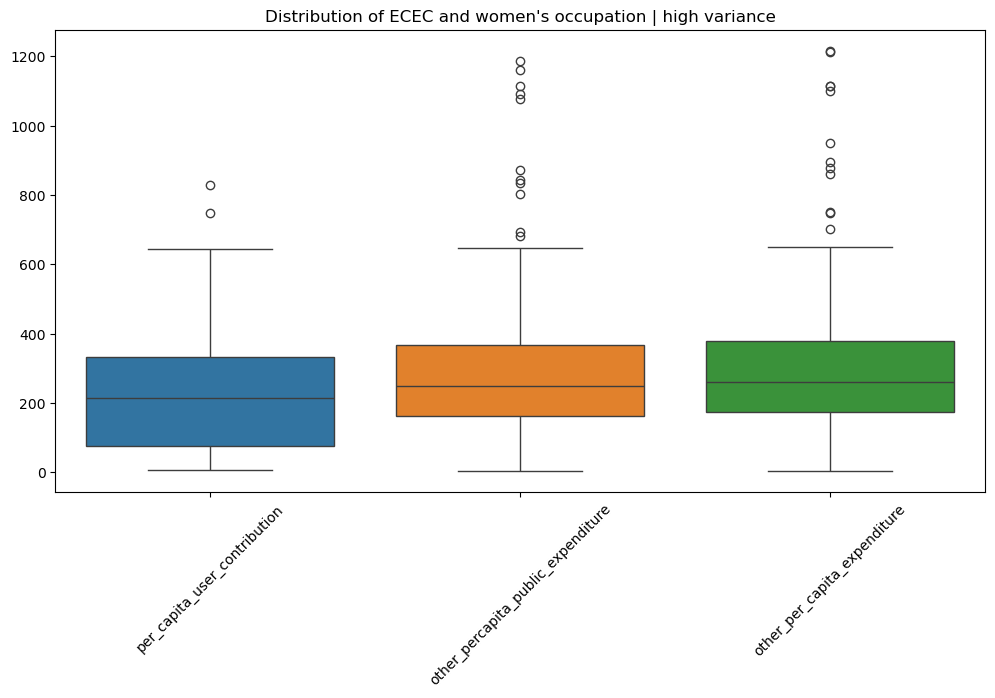

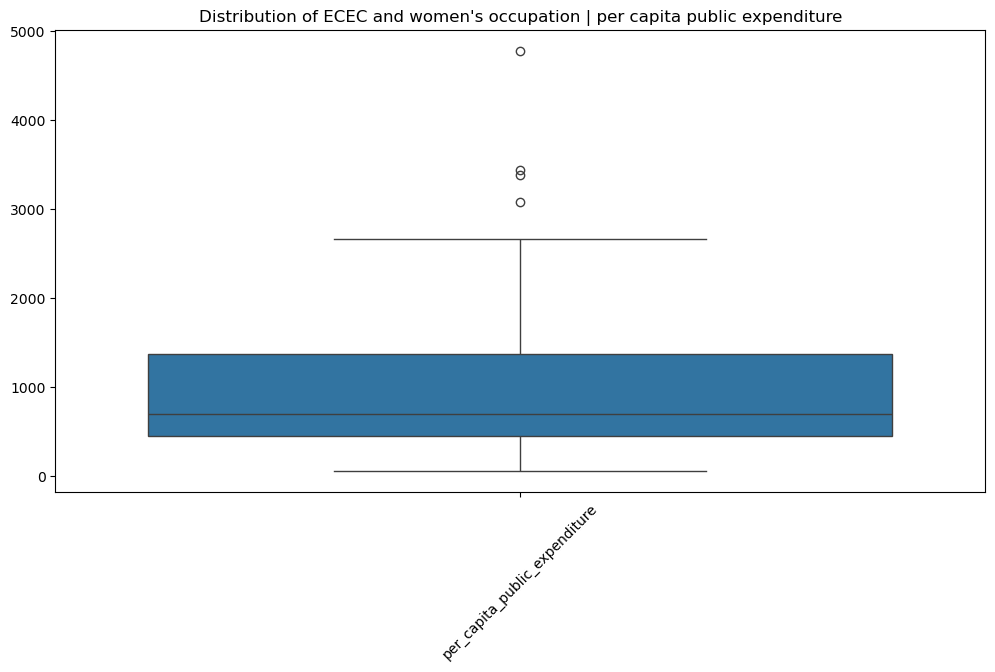

In [133]:
for group_name, var_list in variables_by_stdev.items():
    
    plt.figure(figsize=(12,6))
    sns.boxplot(eda_df[var_list])
    plt.xticks(rotation=45)
    plt.title(f"Distribution of ECEC and women's occupation | {group_name}")
    plt.show()

#TODO : add back prov_code so we can plot 'outliers' labels

Correlation for ECEC / Women's occupation's variables

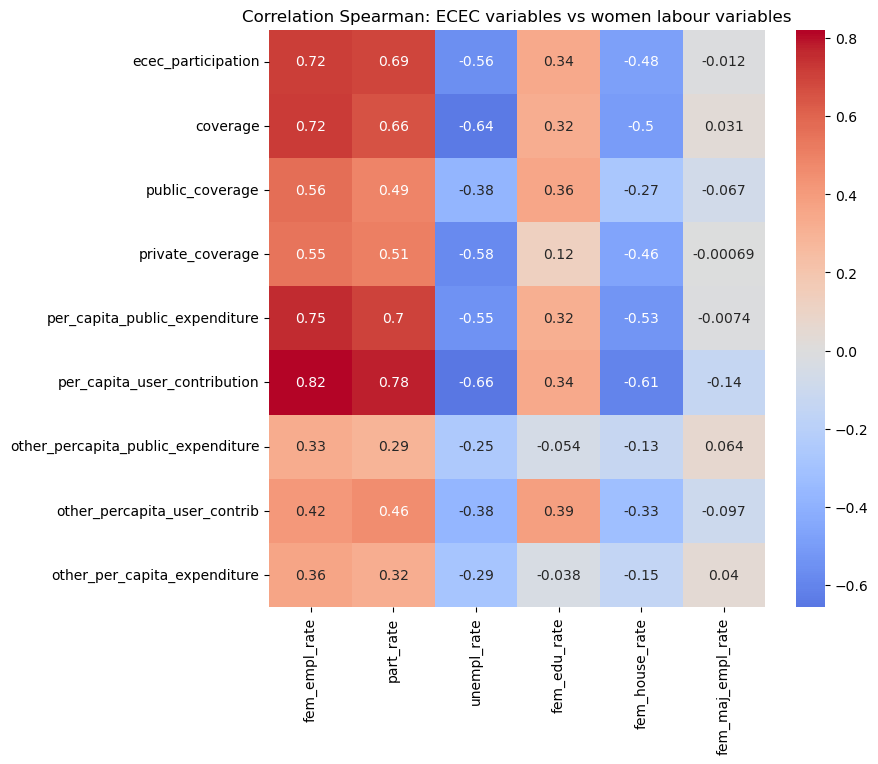

,fem_empl_rate,part_rate,unempl_rate,fem_edu_rate,fem_house_rate,fem_maj_empl_rate
ecec_participation,0.716565,0.692780,-0.558613,0.341399,-0.482837,-0.011849
coverage,0.720143,0.658565,-0.643399,0.324634,-0.503497,0.030731
public_coverage,0.562105,0.492045,-0.384518,0.357413,-0.273820,-0.067497
private_coverage,0.547079,0.509641,-0.577175,0.123881,-0.462848,-0.000686
per_capita_public_expenditure,0.752824,0.704883,-0.551809,0.318707,-0.532700,-0.007357
per_capita_user_contribution,0.821566,0.776828,-0.656018,0.341317,-0.607761,-0.141059
other_percapita_public_expenditure,0.325676,0.291062,-0.253311,-0.054233,-0.129323,0.064421
other_percapita_user_contrib,0.416115,0.456988,-0.378448,0.387612,-0.325544,-0.097335
other_per_capita_expenditure,0.361218,0.323772,-0.285296,-0.037981,-0.153353,0.039656


In [134]:
corr = gdf_num[ecec_variables + labour_variables].corr(method="spearman")

cross_corr = corr.loc[ecec_variables, labour_variables]

plt.figure(figsize=(8, len(ecec_variables)*0.5 + 3))
sns.heatmap(cross_corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Spearman: ECEC variables vs women labour variables")
plt.show()

cross_corr

In [135]:
abs_corr = cross_corr.abs().stack().sort_values(ascending=False)
abs_corr

per_capita_user_contribution        fem_empl_rate        0.821566
                                    part_rate            0.776828
per_capita_public_expenditure       fem_empl_rate        0.752824
coverage                            fem_empl_rate        0.720143
ecec_participation                  fem_empl_rate        0.716565
per_capita_public_expenditure       part_rate            0.704883
ecec_participation                  part_rate            0.692780
coverage                            part_rate            0.658565
per_capita_user_contribution        unempl_rate          0.656018
coverage                            unempl_rate          0.643399
per_capita_user_contribution        fem_house_rate       0.607761
private_coverage                    unempl_rate          0.577175
public_coverage                     fem_empl_rate        0.562105
ecec_participation                  unempl_rate          0.558613
per_capita_public_expenditure       unempl_rate          0.551809
private_co

### Spatial Visualisation

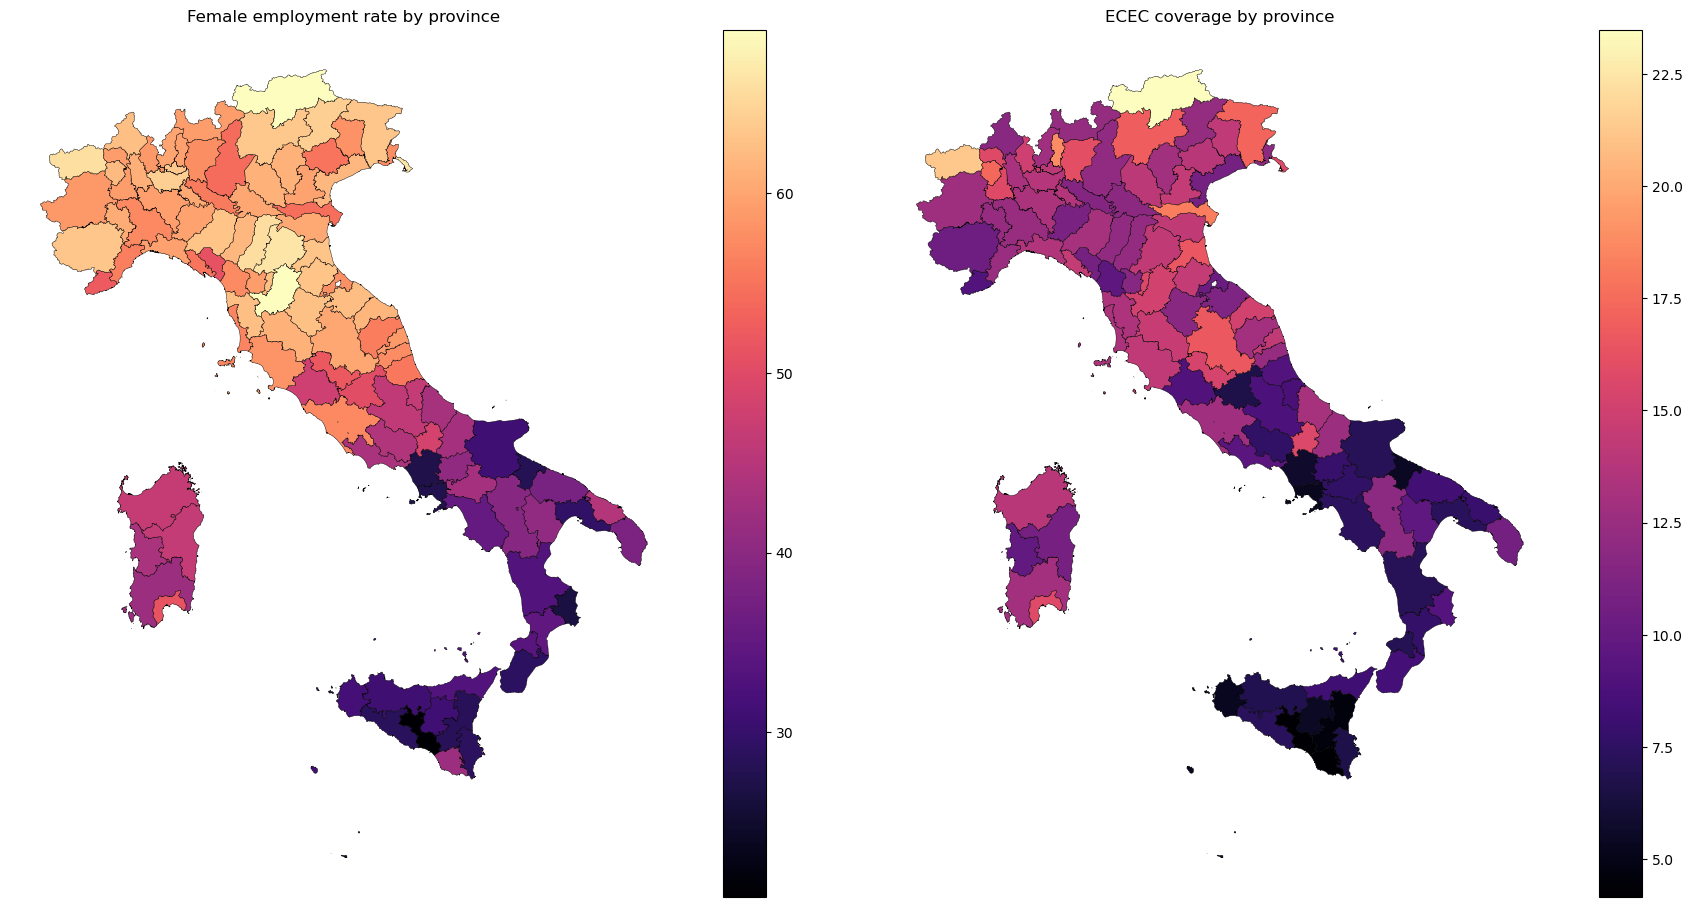

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9))

gdf.plot(
    column="fem_empl_rate",
    cmap="magma",
    legend=True,
    ax=axs[0],
    edgecolor="black",
    linewidth=0.3
)
axs[0].set_title("Female employment rate by province")
axs[0].axis("off")

gdf.plot(
    column="coverage",
    cmap="magma",
    legend=True,
    ax=axs[1],
    edgecolor="black",
    linewidth=0.3
)
axs[1].set_title("ECEC coverage by province")
axs[1].axis("off")

plt.tight_layout()
plt.show()


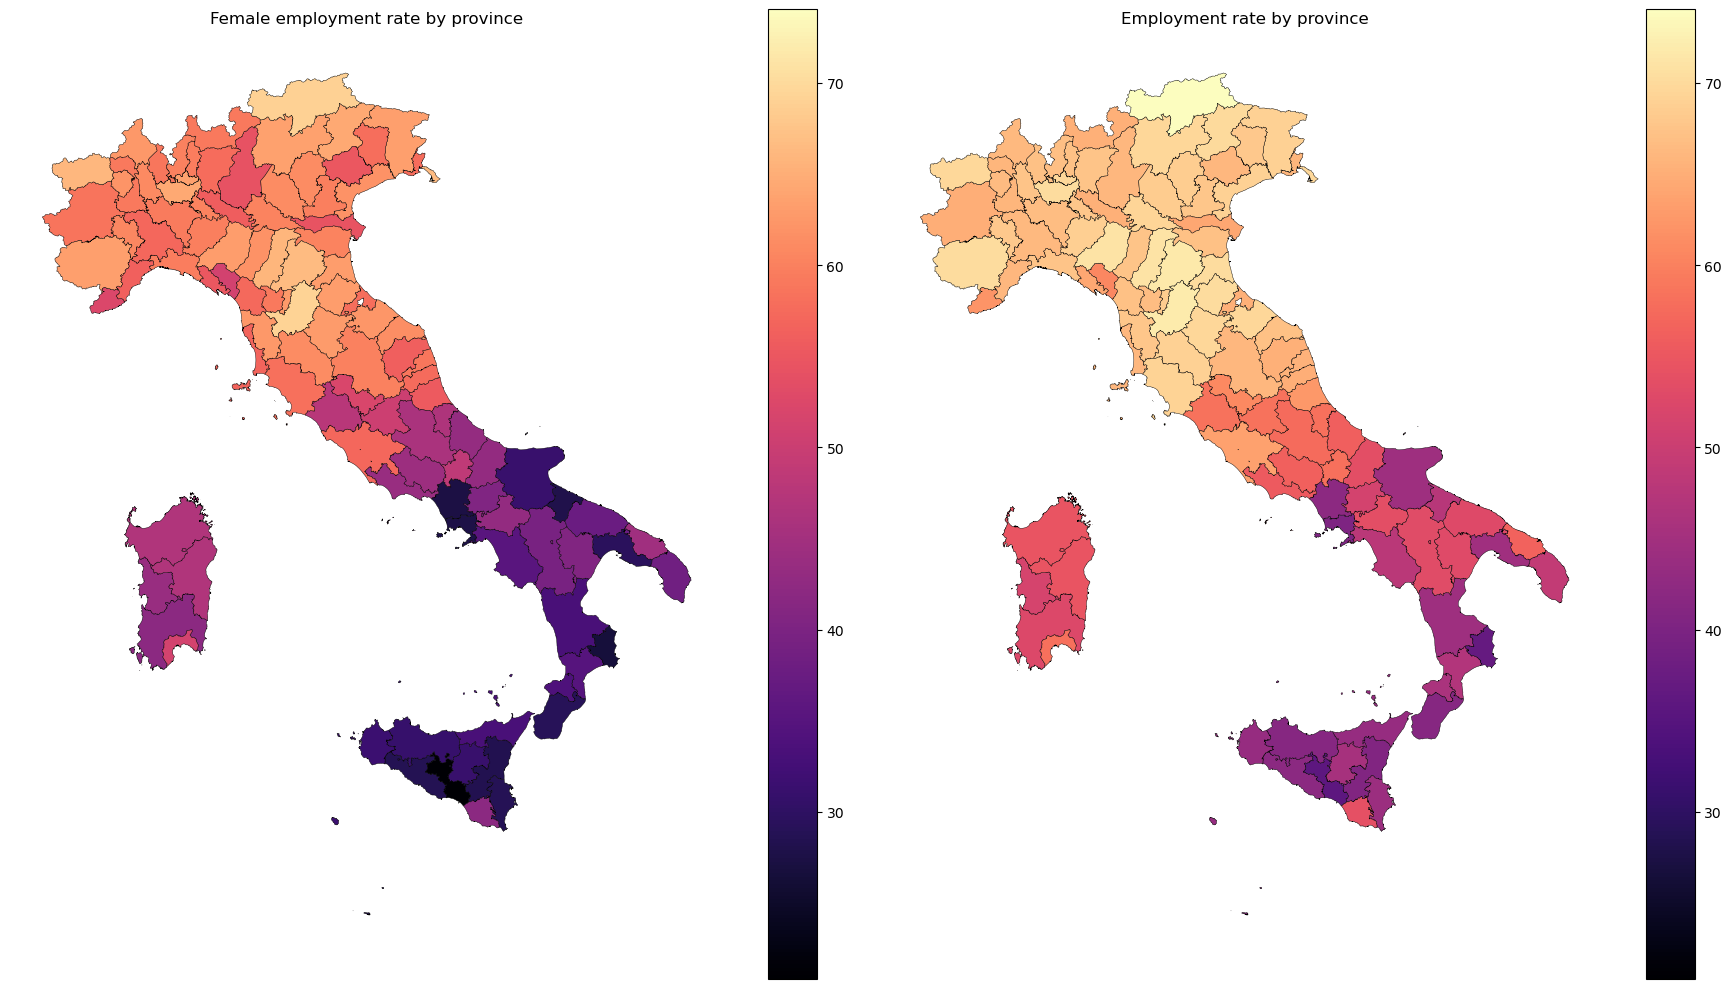

In [137]:
fig, axs = plt.subplots(1, 2, figsize=(18, 10))

# Compute global color limits
vmin = gdf[["fem_empl_rate", "empl_rate"]].min().min()
vmax = gdf[["fem_empl_rate", "empl_rate"]].max().max()

# Female employment rate
gdf.plot(
    column="fem_empl_rate",
    cmap="magma",
    edgecolor="black",
    linewidth=0.3,
    ax=axs[0],
    legend=True,
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)
axs[0].set_title("Female employment rate by province")
axs[0].axis("off")

# Total employment rate
gdf.plot(
    column="empl_rate",
    cmap="magma",
    edgecolor="black",
    linewidth=0.3,
    ax=axs[1],
    legend=True,
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)
axs[1].set_title("Employment rate by province")
axs[1].axis("off")

plt.tight_layout()
plt.show()



Let's focus on the differences between the global employement rate and the female employement rate

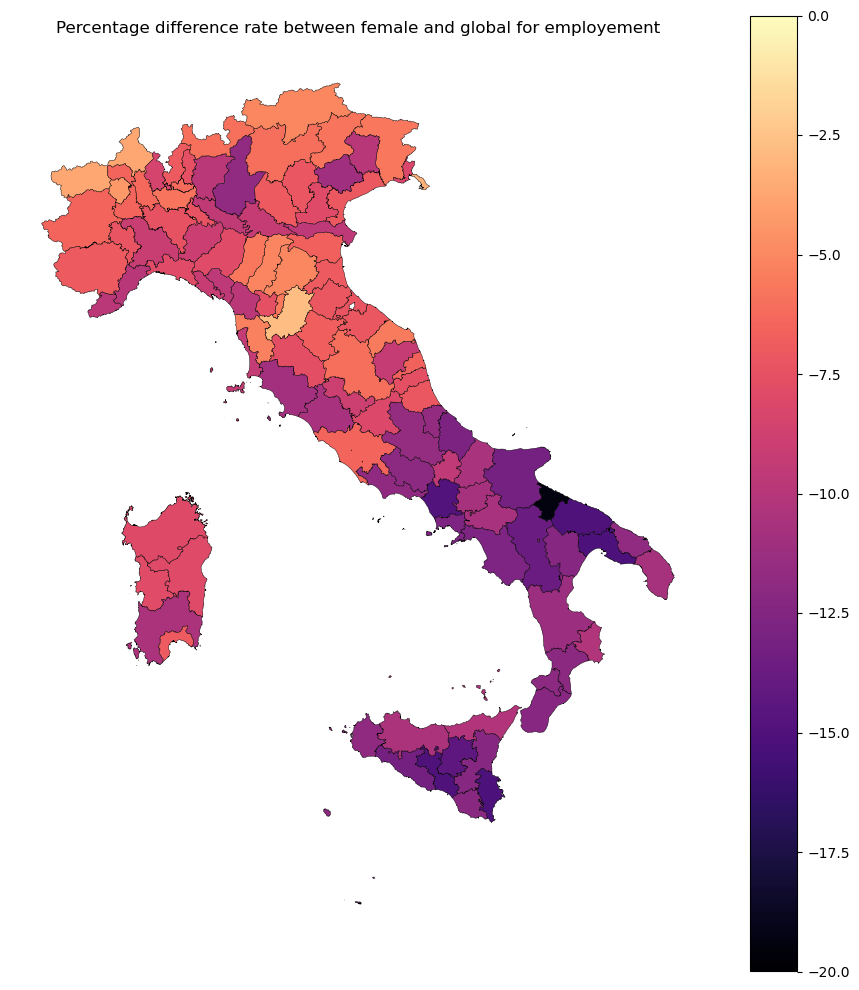

maximal value : -2.76
minimal value : -19.4


In [138]:
gdf_copy=gdf.copy()

gdf_copy["diff_empl_female_vs_glob"]=gdf["fem_empl_rate"]-gdf["empl_rate"]

vmin=round(min(gdf_copy["diff_empl_female_vs_glob"]),2)
vmax=round(max(gdf_copy["diff_empl_female_vs_glob"]),2)


ax = gdf_copy.plot(
    column="diff_empl_female_vs_glob",
    cmap="magma",
    edgecolor="black",
    vmin=-20,
    vmax=0,
    linewidth=0.3,
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)




plt.title("Percentage difference rate between female and global for employement")
plt.axis("off")
plt.tight_layout()
plt.show()
print("maximal value :",vmax)
print("minimal value :",vmin)

### Analysis of occupational gap

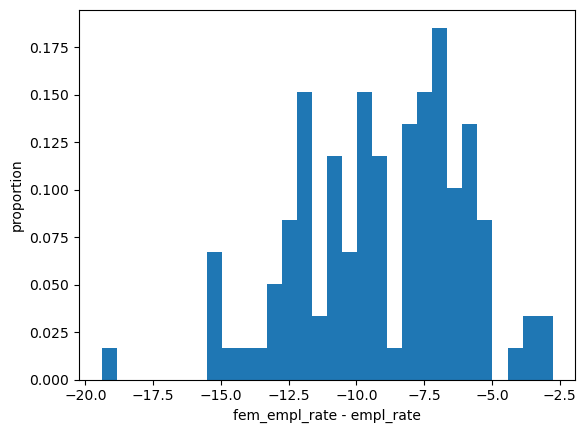

third quartile :  -6.959999999999997


In [139]:
plt.hist(gdf_copy["diff_empl_female_vs_glob"],bins=30, density=True)

plt.xlabel("fem_empl_rate - empl_rate")
plt.ylabel("proportion")
plt.show()

third_quartile=gdf_copy["diff_empl_female_vs_glob"].quantile(q=0.75)

print("third quartile : ",third_quartile)


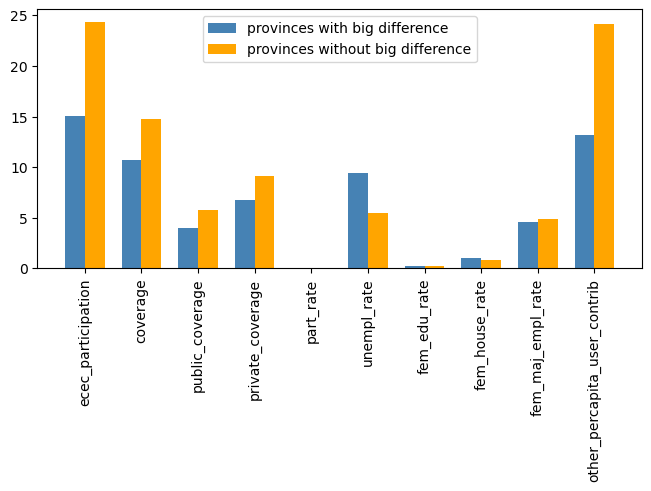

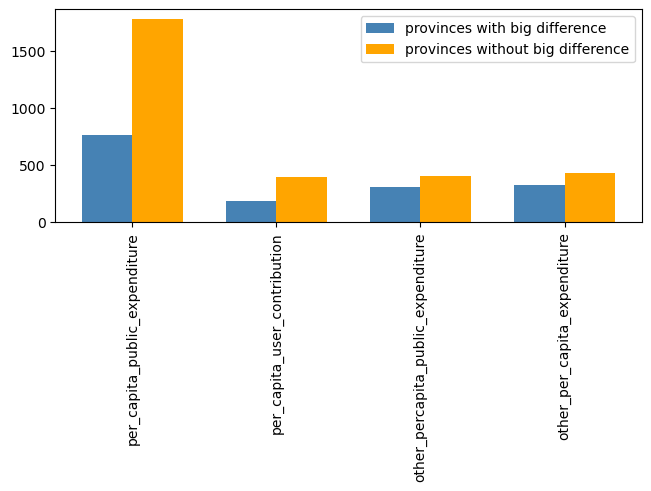

In [140]:
gdf_copy["big_difference_male_vs_female"]=0
gdf_copy.loc[ gdf_copy["diff_empl_female_vs_glob"]<third_quartile ,"big_difference_male_vs_female"]=1

scale1_var=[
    "ecec_participation", "coverage",
    "public_coverage", "private_coverage",
    "part_rate", "unempl_rate",
    "fem_edu_rate", "fem_house_rate", "fem_maj_empl_rate","other_percapita_user_contrib"

]

scale2_var=[ "per_capita_public_expenditure", "per_capita_user_contribution",  "other_percapita_public_expenditure","other_per_capita_expenditure"]


mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale1_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale1_var].mean(axis=0)

fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(scale1_var))
width = 0.35  

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale1_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


fig, ax = plt.subplots(layout='constrained')
x = np.arange(len(scale2_var))

mean_list_1=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==1,scale2_var].mean(axis=0)
mean_list_0=gdf_copy.loc[gdf_copy["big_difference_male_vs_female"]==0,scale2_var].mean(axis=0)

ax.bar(x, mean_list_1, width, label='provinces with big difference', color='steelblue')
ax.bar(x+width, mean_list_0, width, label='provinces without big difference', color='orange')

ax.set_xticks(x+width/2, scale2_var)
ax.tick_params(axis='x', rotation=90)
ax.legend(loc='upper left', ncols=3)
plt.legend()
plt.show()


### Check spatial autocollinearity

In [141]:
gdf_check = gdf_subset.copy()
gdf_check = gpd.GeoDataFrame(gdf_check, geometry=gdf.geometry)
w = libpysal.weights.Queen.from_dataframe(gdf_check, use_index=True)
w.transform = 'r'

for col in gdf_check.select_dtypes(include='number').columns:
    y = gdf_check[col].values
    moran = esda.Moran(y, w)
    print(f"{col}: Moran's I = {moran.I} | p-value = {moran.p_sim}")

/home/alexis/anaconda3/envs/geo/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


fem_edu_rate: Moran's I = 0.16445991612883132 | p-value = 0.006
service_empl_rate: Moran's I = 0.18095693561948895 | p-value = 0.006
dependency_rate: Moran's I = 0.5264410836644587 | p-value = 0.001
graduate_mobility_rate: Moran's I = 0.6477011444774634 | p-value = 0.001
per_capita_public_expenditure: Moran's I = 0.5091312510233326 | p-value = 0.001
ecec_participation: Moran's I = 0.691492301259031 | p-value = 0.001
coverage: Moran's I = 0.5680714866113351 | p-value = 0.001
per_capita_user_contribution: Moran's I = 0.5765270515854904 | p-value = 0.001
fem_maj_empl_rate: Moran's I = 0.10057348720296877 | p-value = 0.055
fem_empl_rate: Moran's I = 0.8671262898001075 | p-value = 0.001


Focusing on our response variable `fem_empl_rate`, I investigate Moran's I clusters

In [142]:
def plot_moran_clusters(gdf, var):
    """
    Plots clusters based on Local Moran's I for a given variable.
    gdf: GeoDataFrame with geometry and variable columns
    var: str, name of the variable column to analyze
    """
    # initialise weights and select variable
    w = libpysal.weights.Queen.from_dataframe(gdf, use_index=True)
    w.transform = 'r'
    y = gdf_check[var].values

    # compute moran's I and clusters
    lm = esda.Moran_Local(y, w)
    sig = lm.p_sim < 0.05
    labels = np.array(['Not significant'] * len(lm.q))
    labels[(lm.q == 1) & sig] = 'HH'
    labels[(lm.q == 2) & sig] = 'LH'
    labels[(lm.q == 3) & sig] = 'LL'
    labels[(lm.q == 4) & sig] = 'HL'
    gdf_check['cluster'] = labels

    # plot clusters
    cluster_colors = {'HH':'red', 'LL':'blue', 'HL':'pink', 'LH':'cyan'}
    cluster_labels = {
        'HH': 'High-High (hotspot)',
        'LL': 'Low-Low (coldspot)',
        'HL': 'High-Low (outlier)',
        'LH': 'Low-High (outlier)'
    }

    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_check.plot(color='lightgrey', ax=ax)

    for cluster, color in cluster_colors.items():
        subset = gdf_check[gdf_check['cluster'] == cluster]
        if not subset.empty:
            subset.plot(color=color, ax=ax)

    patches = [mpatches.Patch(color=color, label=cluster_labels[cluster])
            for cluster, color in cluster_colors.items()
            if not gdf_check[gdf_check['cluster']==cluster].empty]

    plt.legend(handles=patches, title="Local Moran's I Clusters")
    ax.set_title(f"{var}: Local Moran's I Clusters")
    ax.axis('off')
    plt.show()


/home/alexis/anaconda3/envs/geo/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


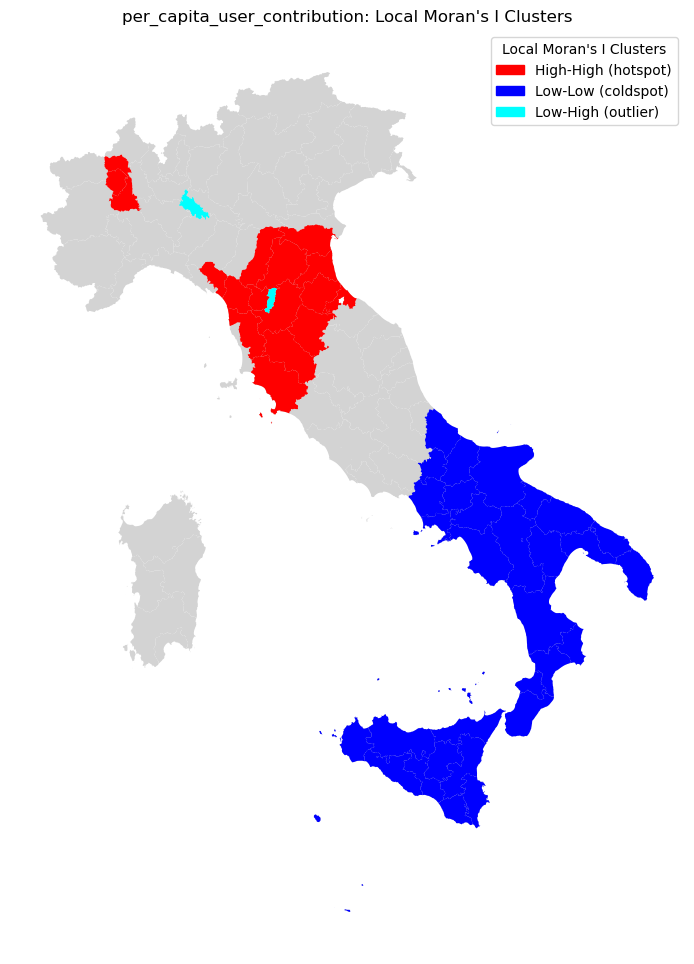

In [143]:
plot_moran_clusters(gdf, 'per_capita_user_contribution')

/home/alexis/anaconda3/envs/geo/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


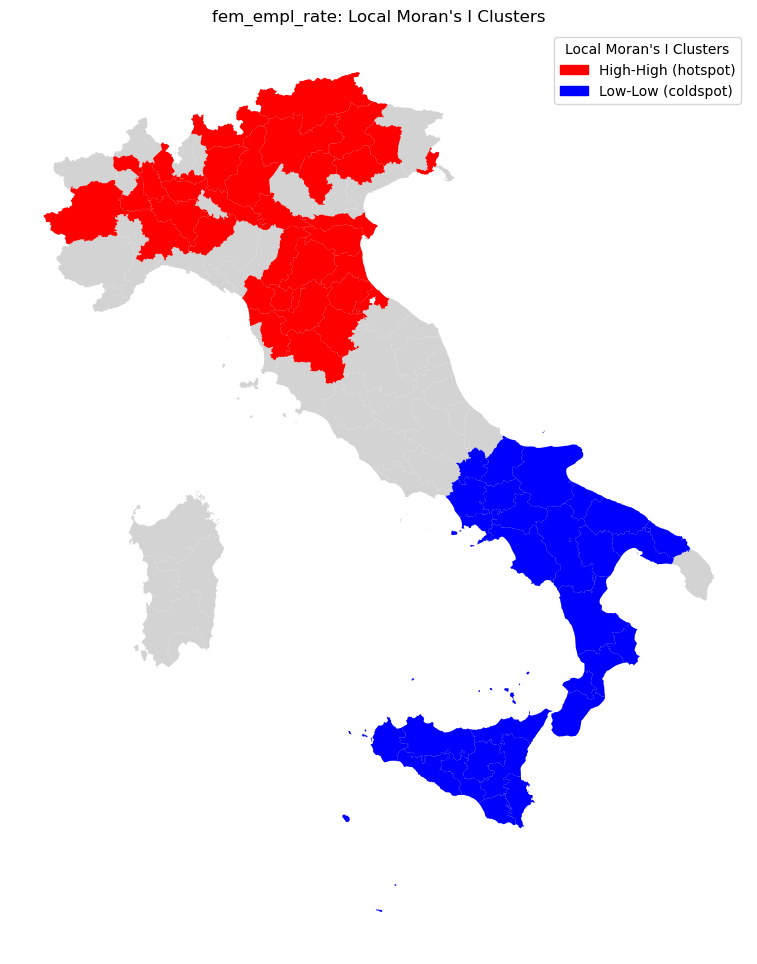

In [144]:
plot_moran_clusters(gdf, 'fem_empl_rate')

/home/alexis/anaconda3/envs/geo/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


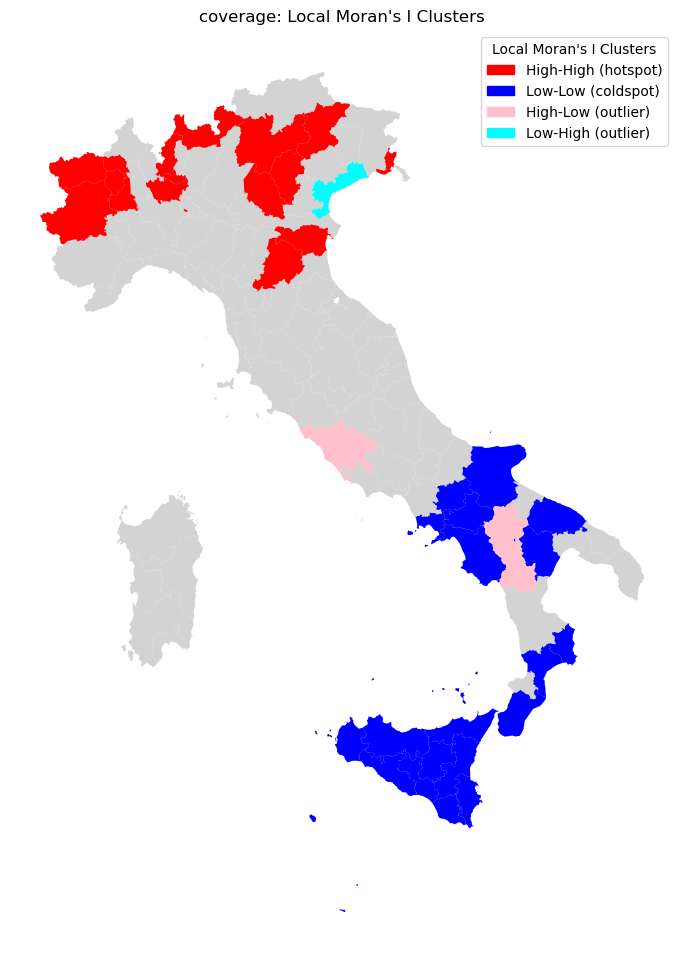

In [145]:
plot_moran_clusters(gdf, 'coverage')

### Latent dimension? (or naive PCA attempt)

I make a naive attempt at PCA, just for exploratory purposes. <br>
The aim of this section is the following:
- standardise variables and compute PCA
- evaluate how much variance is explained by the first few PCs
- try to interpret the loadings of such PCs
- plot the observations on the plane identified by the first two PCs

In [146]:
# first standardise vars, then compute PCA
X = gdf.select_dtypes(include='number').dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pd.Series(pca.explained_variance_ratio_, name='Explained Variance')

In [147]:

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print(loadings)

                                         PC1       PC2       PC3       PC4  \
population                          0.028669 -0.297200  0.105103  0.036216   
unempl_rate                        -0.193553 -0.074668  0.131147  0.024115   
part_rate                           0.217614  0.012803 -0.102504 -0.023142   
empl_growth                         0.007373 -0.031235 -0.053481 -0.018368   
inact_rate                         -0.219732 -0.068522  0.063983  0.050733   
fem_edu_rate                        0.110160 -0.172091  0.254908 -0.159584   
male_edu_rate                       0.100203 -0.231351  0.234562 -0.191226   
service_empl_rate                  -0.034541 -0.097790  0.331219 -0.017985   
GDP                                 0.202305 -0.129598 -0.041045  0.052845   
n_large_comp                        0.152977 -0.181783 -0.007250  0.019159   
n_self_empl                        -0.112574  0.040709  0.094978 -0.061893   
young_neet                         -0.198342 -0.058029  0.067105

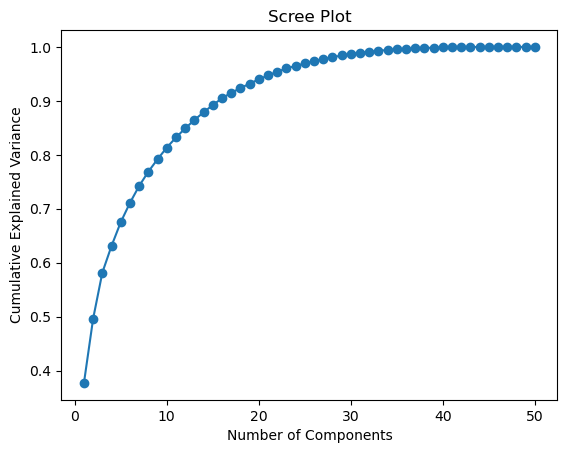

In [148]:

plt.plot(range(1, len(explained) + 1), explained.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.show()

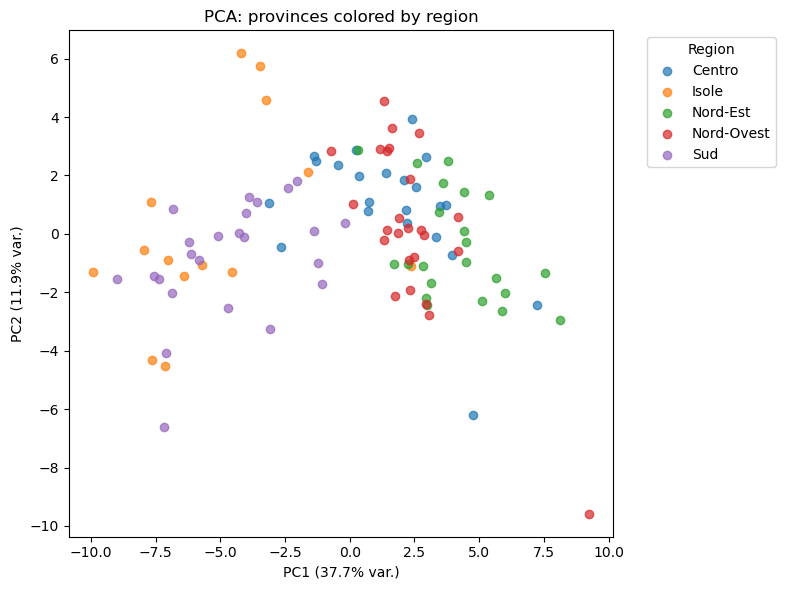

In [149]:
# Scatter plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=gdf.index)
pca_df["rip_name"] = gdf.loc[pca_df.index, "rip_name"]

fig, ax = plt.subplots(figsize=(8, 6))
groups = pca_df.groupby("rip_name")

for name, group in groups:
    ax.scatter(group["PC1"], group["PC2"], label=name, alpha=0.7)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("PCA: provinces colored by region")
ax.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusions** <br>
It takes a lot of PCs to explain a significant chunk of the variance. The first two only account for 48%. <br>
Intuitively, we have the following:
- 1st PC (36% of variance explained)
    - high positive loadings for employment variables (fem_empl_rate, part_rate, empl_rate, GDP)
    - high negative loadings for the opposite variables (unemployment, inactivity, neet)
    - clearly represents high-income, economically active provinces
- 2nd PC (12% of variance explained)
    - high positive loadings with ageing index and dependency rate
    - high negative loadings with population, fertility, and education variables
    - distinguishes between "young" regions, with many residents and high fertility, and provinces with older people, with less educated residents

Overall results: not great tbh

# Linear frequentist model 

Best alpha found: 0.0493

Mean CV R²: 0.999 ± 0.001
Mean CV MSE: 0.143 ± 0.094


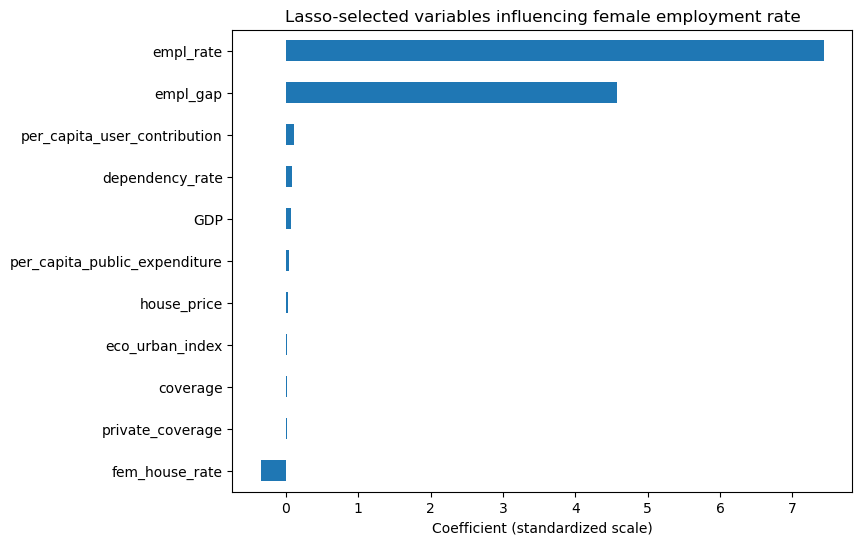

In [150]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

X = gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate']).dropna()
y = gdf.loc[X.index, 'fem_empl_rate']
# y = (y-np.mean(y))/np.std(y)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y)

coef = pd.Series(lasso_final.coef_, index=X.columns)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
# print("\nNon-zero coefficients (variables selected by Lasso):")
# print(nonzero_coef)

r2_scores = cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
plt.title('Lasso-selected variables influencing female employment rate')
plt.xlabel('Coefficient (standardized scale)')
plt.show()

The coefficients of the linear model are meaningfull. Indeed, we see that :
- empl_rate
- ageing index 
- coverage
- per_capita_user_contribution
- ecec participation 

are positively correlated to fem_empl_rate, while others covariates such as 

- n_members_family
- avg_children_per_woman
- fem_house_rate

are negatively correlated.



How does the prediction fit on the data ?



/tmp/ipykernel_8263/200361352.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


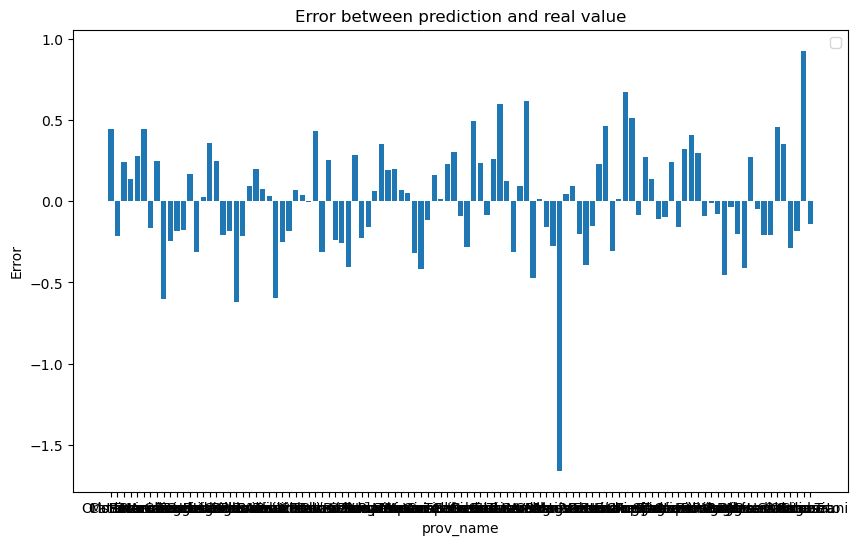

In [151]:
y_pred = lasso_final.predict(X_scaled)

Error=y_pred-y
# Graphique comparatif
plt.figure(figsize=(10,6))
# plt.boxplot(Error)
plt.bar(gdf["prov_name"],Error)
plt.xlabel("prov_name")
plt.ylabel("Error")
plt.title("Error between prediction and real value")
plt.legend()
plt.show()

# Car Leroux model

## Interpretation of the CAR model

In the CAR model, we estimate:

$$
y_i = X_i \beta + u_i + \varepsilon_i
$$

Where:

- **\(X_i \beta\)** — effect of the predictors  
- **\(u_i\)** — spatial effect (CAR component)  
- **\(\varepsilon_i\)** — noise term


### Build adjacency from your GeoDataFrame

In [152]:
gdf = gdf.reset_index(drop=True)

node1 = []
node2 = []
num_neighbors = np.zeros(len(gdf), dtype=int)

for i, g1 in enumerate(gdf.geometry):
    for j, g2 in enumerate(gdf.geometry):
        # Only count each pair once (i < j)
        if i < j and g1.touches(g2):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)
            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.array(node1, dtype=int)
node2 = np.array(node2, dtype=int)

### Prepare data

In [153]:
print(X.columns)

Index(['population', 'unempl_rate', 'part_rate', 'empl_growth', 'inact_rate',
       'fem_edu_rate', 'male_edu_rate', 'service_empl_rate', 'GDP',
       'n_large_comp', 'n_self_empl', 'young_neet', 'fem_house_rate',
       'foreign_rate', 'n_members_family', 'elderly_in_care', 'house_price',
       'fertility_rate', 'first_birth_maternal_age', 'avg_children_per_woman',
       'dependency_rate', 'ageing_index', 'net_migration_rate',
       'adj_net_migration_rate', 'area_km2', 'public_transport_supply',
       'internet_coverage_rate', 'graduate_mobility_rate', 'green_m2_capita',
       'eco_urban_index', 'per_capita_public_expenditure',
       'ecec_participation', 'coverage', 'urban_type',
       'per_capita_user_contribution', 'advanced_business_empl',
       'lifelong_learn', 'startup_ratio', 'GERD_total_intramural',
       'public_coverage', 'private_coverage',
       'other_percapita_public_expenditure', 'other_percapita_user_contrib',
       'other_per_capita_expenditure', 'fem_m

In [169]:
selected_covariates = ['ageing_index', 'avg_children_per_woman', 'coverage', 'ecec_participation', 'fem_house_rate', 'fem_maj_empl_rate', 'n_members_family', 'net_migration_rate', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'per_capita_public_expenditure', 'per_capita_user_contribution', 'public_coverage', 'service_empl_rate']

X = gdf.select_dtypes(include="number").drop(columns=["fem_empl_rate"])
X = X.fillna(X.mean())  # simple sanitization
#X= X[selected_covariates]
y = gdf["fem_empl_rate"].values
y = y / 100
y = np.log(y / (1 - y))
x_offset = X["mal_empl_rate"].values
x_offset=x_offset/100   
x_offset = np.log(x_offset / (1 - x_offset))


stan_data = {
    "N": len(gdf),
    "P": X.shape[1],
    "y": y,
    "X": X.values,
    "N_edges": len(node1),
    "x_offset": x_offset,
    "node1": node1,
    "node2": node2,
    "num_neighbors": num_neighbors,
}



### Compile the CAR model

In [170]:
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="car_leroux_model.stan", cpp_options={"O0":""})

### Run the CAR model

In [171]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42
)


11:33:11 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]




chain 1:   0%|          | 1/2000 [00:00<03:24,  9.80it/s, (Warmup)]












chain 1:  10%|█         | 200/2000 [00:12<01:56, 15.47it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:20<02:04, 13.68it/s, (Warmup)]

chain 1:  20%|██        | 400/2000 [00:28<02:02, 13.09it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:38<02:04, 12.06it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:48<02:07, 10.98it/s, (Warmup)]




chain 1:  35%|███▌      | 700/2000 [00:58<01:58, 10.99it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [01:07<01:49, 10.99it/s, (Warmup)]



chain 1:  45%|████▌     | 900/2000 [01:14<01:35, 11.56it/s, (Warmup)]



chain 1:  50%|█████     | 1000/2000 [01:23<01:27, 11.42it/s, (Sampling)]




chain 1:  55%|█████▌    | 1100/2000 [01:36<01:30,  9.94it/s, (Sampling)]





chain 1:  60%|██████    | 1200/2000 [01:45<01:16, 10.41it/s, (Sampling)]






chain 1:  70%|███████   | 1400/2000 [02:01<00:52, 11.34it/s, (Sampling)]


chain 2: 100%|██████████| 200


11:35:56 - cmdstanpy - INFO - CmdStan done processing.


11:35:57 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 54 divergent transitions (5.4%)
	Chain 1 had 945 iterations at max treedepth (94.5%)
	Chain 2 had 151 divergent transitions (15.1%)
	Chain 2 had 848 iterations at max treedepth (84.8%)
	Chain 3 had 2 divergent transitions (0.2%)
	Chain 3 had 997 iterations at max treedepth (99.7%)
	Chain 4 had 601 divergent transitions (60.1%)
	Chain 4 had 398 iterations at max treedepth (39.8%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


### Extract posterior quantities

In [172]:
beta_post = fit.stan_variable("beta")
spatial_post = fit.stan_variable("u")
sigma_post = fit.stan_variable("sigma")
tau_post = fit.stan_variable("tau")
rho_post = fit.stan_variable("rho")


Posterior means:

In [173]:
beta_mean = beta_post.mean(axis=0)
spatial_mean = spatial_post.mean(axis=0)

gdf["spatial_effect"] = spatial_mean

### Plot the spatial effect

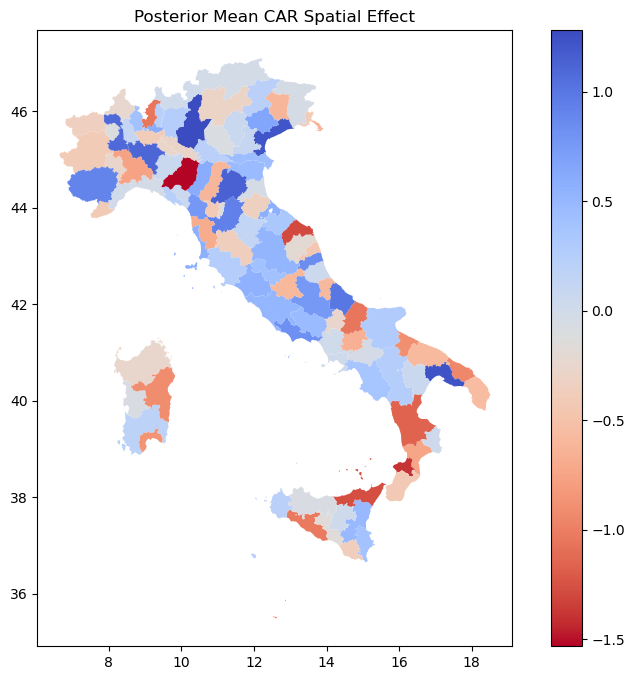

In [174]:
gdf.plot(column="spatial_effect", cmap="coolwarm_r", legend=True, figsize=(10,8))
plt.title("Posterior Mean CAR Spatial Effect")
plt.show()


### Plot regression coefficients

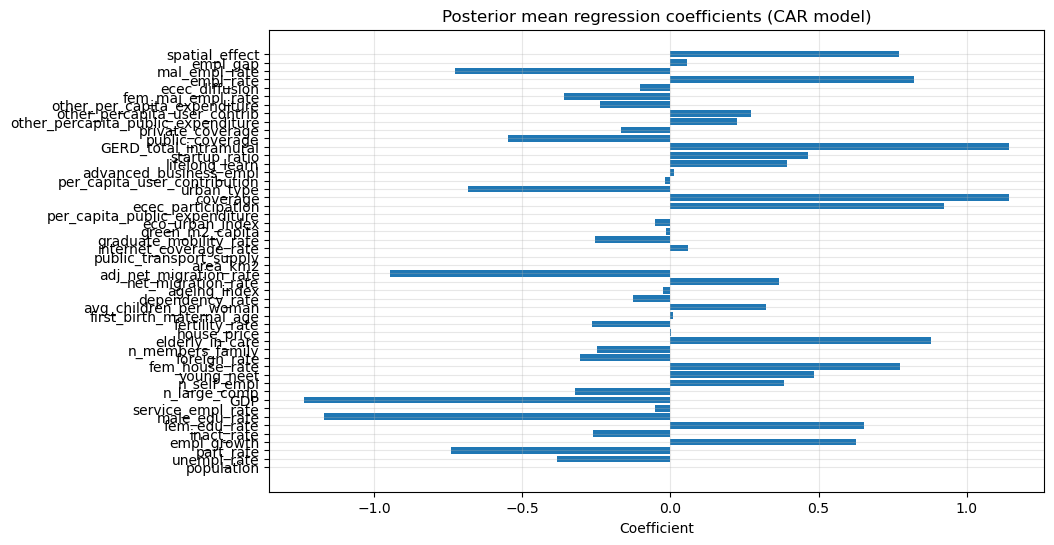

In [175]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, beta_mean)
plt.title("Posterior mean regression coefficients (CAR model)")
plt.xlabel("Coefficient")
plt.grid(True, alpha=0.3)
plt.show()

### Plot sigma, tau, phi posteriors

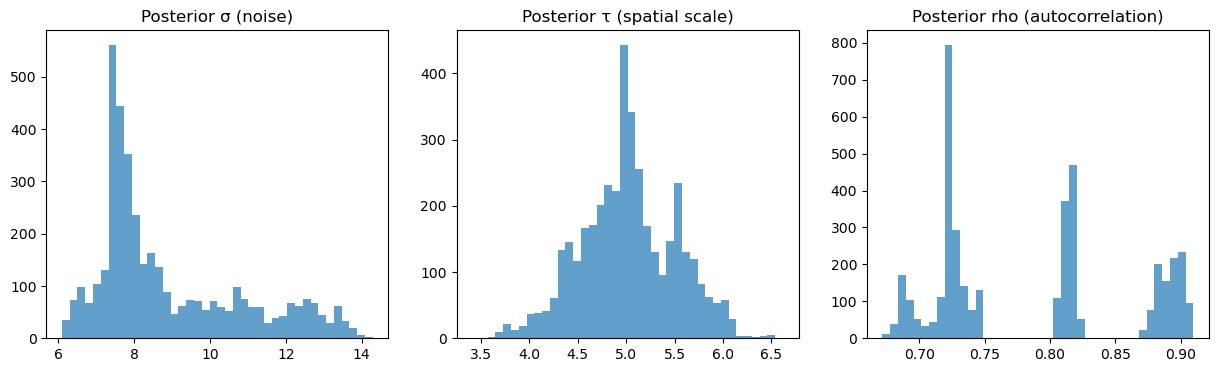

In [176]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(sigma_post, bins=40, alpha=0.7)
axs[0].set_title("Posterior σ (noise)")

axs[1].hist(tau_post, bins=40, alpha=0.7)
axs[1].set_title("Posterior τ (spatial scale)")

axs[2].hist(rho_post, bins=40, alpha=0.7)
axs[2].set_title("Posterior rho (autocorrelation)")

plt.show()


τ 

τ controls the overall magnitude of the spatial effect:

τ big → strong spatial variation (big differences between regions)

τ small → weak spatial variation

rho

rho=how much each region is influenced by its neighbors

rho≈1 → strong spatial dependence
(classic ICAR behavior, strong clustering)

rho≈0 → almost no spatial effect
(each region behaves independently)

Interpretation:

rho close to 1 → strong spatial autocorrelation

τ large → strong spatial variation

σ small → predictors + CAR explain most of the data

# Car BYM2 model

## Interpretation of the CAR model

In the CAR model, we estimate:

$$
y_i = X_i \beta + u_i + \varepsilon_i
$$

Where:

- **\(X_i \beta\)** — effect of the predictors  
- **\(u_i\)** — spatial effect (CAR component)  
- **\(\varepsilon_i\)** — noise term


### Build adjacency from your GeoDataFrame

In [ ]:
gdf = gdf.reset_index(drop=True)

node1 = []
node2 = []
num_neighbors = np.zeros(len(gdf), dtype=int)

for i, g1 in enumerate(gdf.geometry):
    for j, g2 in enumerate(gdf.geometry):
        # Only count each pair once (i < j)
        if i < j and g1.touches(g2):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)
            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.array(node1, dtype=int)
node2 = np.array(node2, dtype=int)

### Prepare data

In [ ]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def compute_scaling_factor(num_neighbors, node1, node2):
    N = len(num_neighbors)

    # Build sparse precision matrix Q for ICAR
    Q = sp.lil_matrix((N, N))

    # Off-diagonal entries
    for a, b in zip(node1, node2):
        Q[a - 1, b - 1] = -1
        Q[b - 1, a - 1] = -1

    # Diagonal entries
    for i in range(N):
        Q[i, i] = num_neighbors[i]

    # Convert to CSR
    Q = Q.tocsr()

    # Compute generalized inverse diagonal (ICAR variance)
    # Solve Q x = I row-by-row
    variances = np.zeros(N)

    for i in range(N):
        e = np.zeros(N)
        e[i] = 1
        # Solve Qx = e in least-squares sense
        x, _ = spla.lsmr(Q, e)[:2]
        variances[i] = x[i]

    # Scaling factor = geometric mean
    scaling_factor = np.exp(np.mean(np.log(variances)))

    return float(scaling_factor)

scaling_factor = compute_scaling_factor(num_neighbors, node1, node2)
print("Scaling factor:", scaling_factor)

Scaling factor: 0.4809535813618575


In [ ]:
X = gdf.select_dtypes(include="number").drop(columns=["fem_empl_rate"])
X = X.fillna(X.mean())  # simple sanitization
#X= X[selected_covariates]
y = gdf["fem_empl_rate"].values

stan_data = {
    "N": len(gdf),
    "P": X.shape[1],
    "y": y,
    "X": X.values,
    "N_edges": len(node1),
    "node1": node1,
    "node2": node2,
    "num_neighbors": num_neighbors,
    "scaling_factor": scaling_factor
}




### Compile the CAR model

In [ ]:
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="car_bym2_model.stan", cpp_options={"O0":""})

### Run the CAR model

In [ ]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42
)


10:03:36 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   0%|          | 1/2000 [00:00<05:39,  5.89it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:00<00:09, 192.10it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:06<01:07, 26.61it/s, (Warmup)] 




chain 1:  15%|█▌        | 300/2000 [00:13<01:31, 18.49it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:22<01:47, 14.89it/s, (Warmup)]



chain 1:  25%|██▌       | 500/2000 [00:31<01:49, 13.70it/s, (Warmup)]

chain 1:  30%|███       | 600/2000 [00:38<01:42, 13.68it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:48<01:45, 12.29it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:54<01:32, 13.00it/s, (Warmup)]




chain 1:  45%|████▌     | 900/2000 [01:01<01:20, 13.63it/s, (Warmup)]



chain 1:  50%|█████     | 1000/2000 [01:08<01:13, 13.63it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [01:15<01:03, 14.22it/s, (Sampling)]


chain 1


10:05:55 - cmdstanpy - INFO - CmdStan done processing.
10:05:55 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'car_bym2_model.stan', line 40, column 2 to column 36)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be f

10:05:56 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 999 iterations at max treedepth (99.9%)
	Chain 2 had 5 divergent transitions (0.5%)
	Chain 2 had 994 iterations at max treedepth (99.4%)
	Chain 3 had 999 iterations at max treedepth (99.9%)
	Chain 4 had 999 iterations at max treedepth (99.9%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


### Extract posterior quantities

In [ ]:
beta_post   = fit.stan_variable("beta")
theta_post  = fit.stan_variable("theta")
phi_post    = fit.stan_variable("phi")
sigma_post  = fit.stan_variable("sigma")
rho_post    = fit.stan_variable("rho")
sigma_y_post = fit.stan_variable("sigma_y")

# final spatial effect (transformed parameter)
u_post      = fit.stan_variable("u")



### Basic posterior summaries

In [ ]:
print("rho mean =", np.mean(rho_post))
print("sigma mean =", np.mean(sigma_post))
print("sigma_y mean =", np.mean(sigma_y_post))

print("\nPosterior means of beta:")
print(pd.DataFrame(beta_post, columns=X.columns).mean())


rho mean = 0.48269692375
sigma mean = 0.9820490307500002
sigma_y mean = 8.393840562500001

Posterior means of beta:
population                           -3.418605e-07
unempl_rate                          -3.121481e-01
part_rate                            -6.106433e-01
empl_rate                             8.546094e-01
empl_growth                           1.895713e-01
inact_rate                            2.071024e-01
fem_edu_rate                         -9.852868e-01
male_edu_rate                        -5.569147e-02
service_empl_rate                    -1.256080e+00
GDP                                  -2.626177e-01
n_large_comp                          4.204671e-01
n_self_empl                           7.608448e-02
young_neet                            3.636276e-01
fem_house_rate                       -7.095119e-01
foreign_rate                         -3.053687e-01
n_members_family                      5.522489e-01
elderly_in_care                       5.773231e-01
house_price      

### Plot posterior distributions

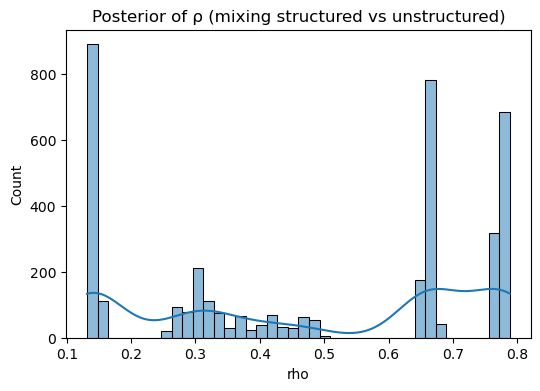

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(rho_post, kde=True, bins=40)
plt.title("Posterior of ρ (mixing structured vs unstructured)")
plt.xlabel("rho")
plt.show()


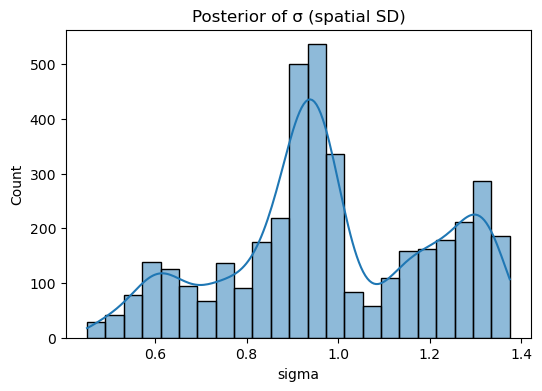

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(sigma_post, kde=True)
plt.title("Posterior of σ (spatial SD)")
plt.xlabel("sigma")
plt.show()


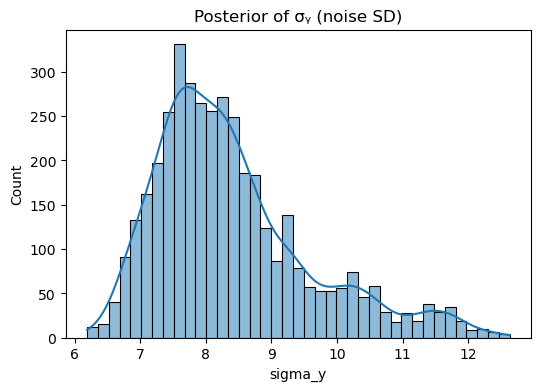

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(sigma_y_post, kde=True)
plt.title("Posterior of σᵧ (noise SD)")
plt.xlabel("sigma_y")
plt.show()


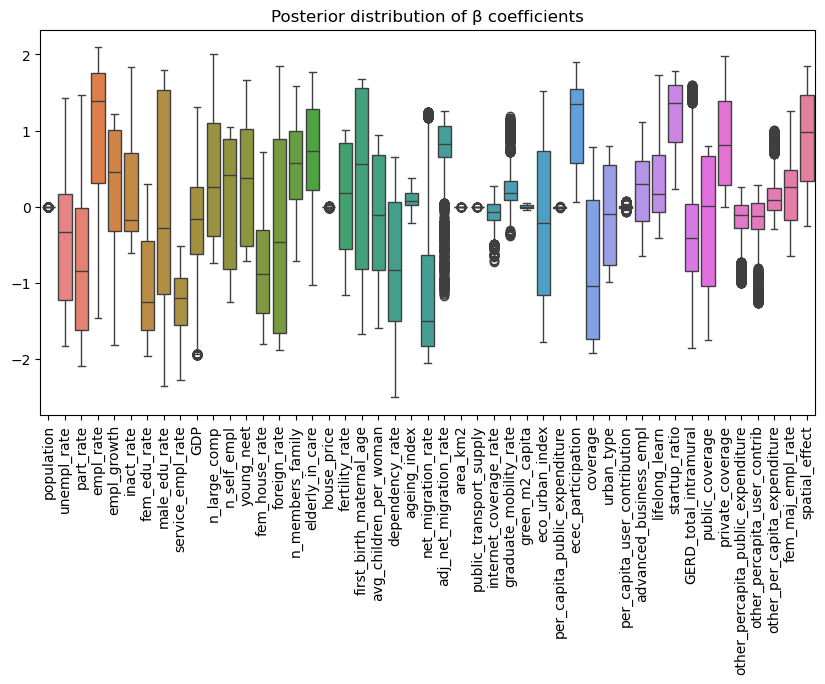

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=pd.DataFrame(beta_post, columns=X.columns))
plt.xticks(rotation=90)
plt.title("Posterior distribution of β coefficients")
plt.show()


### POSTERIOR MAPS

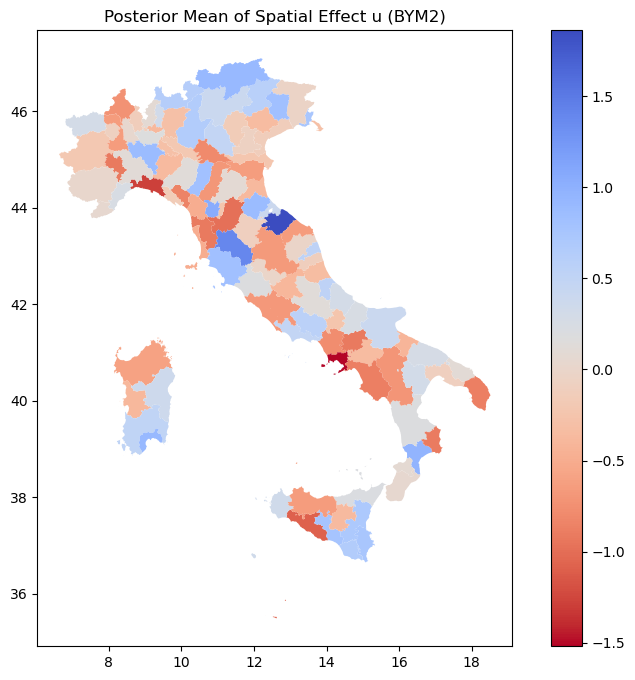

In [ ]:
gdf["u_mean"] = u_post.mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="u_mean", cmap="coolwarm_r", legend=True, ax=ax)
ax.set_title("Posterior Mean of Spatial Effect u (BYM2)")
plt.show()


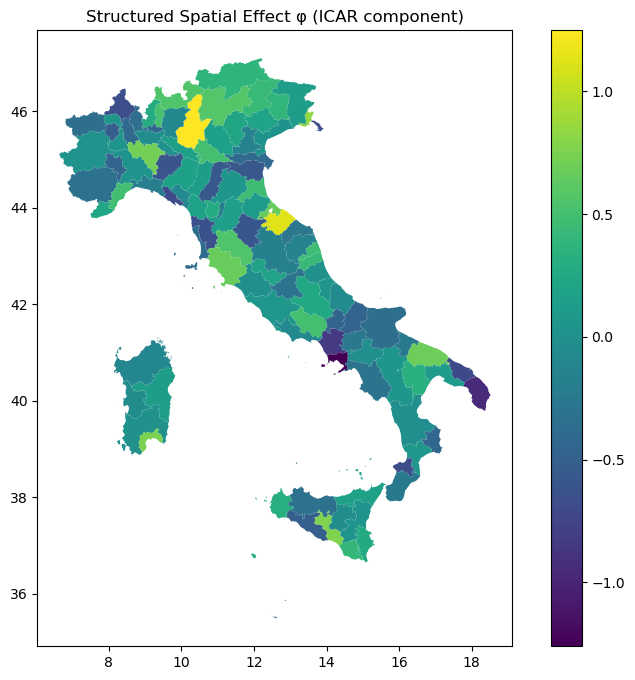

In [ ]:
gdf["phi_mean"] = phi_post.mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="phi_mean", cmap="viridis", legend=True, ax=ax)
ax.set_title("Structured Spatial Effect φ (ICAR component)")
plt.show()


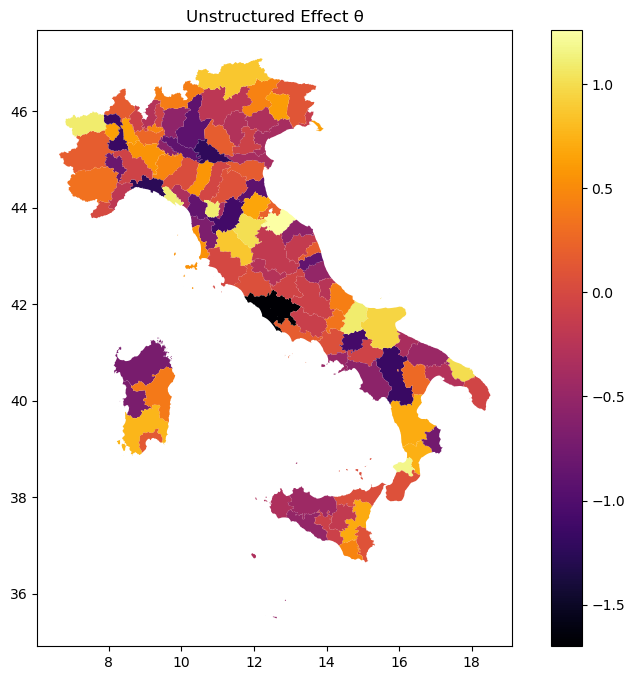

In [ ]:
gdf["theta_mean"] = theta_post.mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="theta_mean", cmap="inferno", legend=True, ax=ax)
ax.set_title("Unstructured Effect θ")
plt.show()


### CHECK IDENTIFIABILITY: STRUCTURED vs UNSTRUCTURED

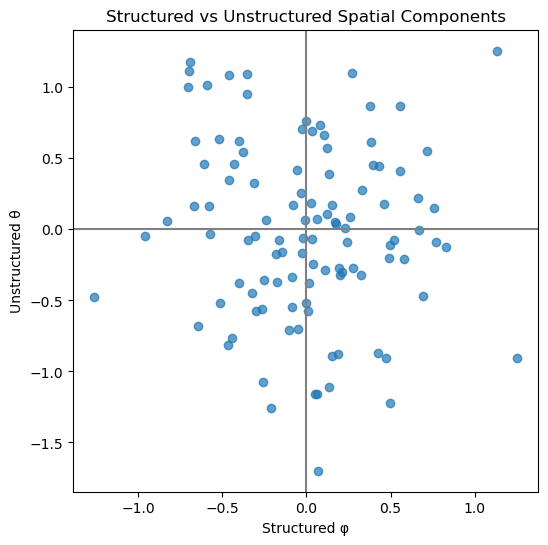

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(phi_post.mean(axis=0), theta_post.mean(axis=0), alpha=0.7)
plt.xlabel("Structured φ")
plt.ylabel("Unstructured θ")
plt.title("Structured vs Unstructured Spatial Components")
plt.axhline(0, color="gray")
plt.axvline(0, color="gray")
plt.show()


### POSTERIOR PREDICTIVE MEAN MAP

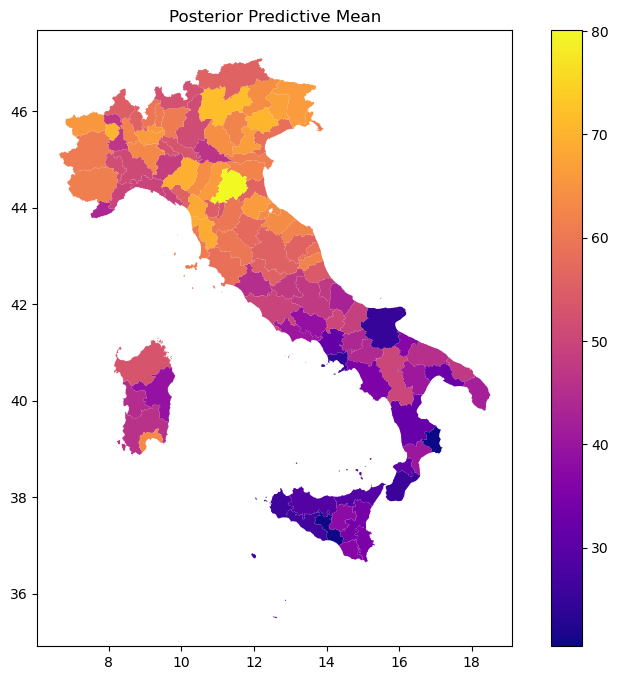

In [ ]:
beta_mean = beta_post.mean(axis=0)

yhat = X.values @ beta_mean + u_post.mean(axis=0)
gdf["yhat"] = yhat

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="yhat", cmap="plasma", legend=True, ax=ax)
ax.set_title("Posterior Predictive Mean")
plt.show()
